In [73]:
!pip install rapidfuzz


# **Abstract**

The price of a used car is influenced by multiple factors such as age, mileage, brand, fuel type, and technical characteristics, making accurate price estimation a complex task. The objective of this project is to develop a consistent model assessment strategy that allows the creation and comparison of different candidate regression models in order to identify the most generalizable one for predicting car prices.

The work started with an exploratory analysis of the dataset to understand feature distributions and identify data quality issues. A major challenge during data preparation was the cleaning of categorical variables, particularly brand and model names, which contained numerous inconsistencies and misspellings. To address this, a hybrid fuzzy string matching approach was applied, combining Euclidean distance and Levenshtein distance to standardise equivalent values. Missing data was handled using appropriate imputation methods, while numerical features were scaled and categorical features were encoded. The dataset was split into training and test sets, with all model training, comparison, and hyperparameter tuning performed exclusively on the training data.

In total, six different regression models were developed and evaluated using a consistent assessment strategy, enabling a fair comparison of their performance and generalisation capability. The best results, in terms of Mean Absolute Error (MAE), were achieved using a blended model combining Extra Trees, Random Forest, and Histogram Gradient Boosting. In addition, an analytics interface was created using Gradio, allowing users to input new vehicle data and instantly receive a predicted price from the trained model.

Future work may focus on feature engineering, expanding the dataset, and improving the user interface to make it more user-friendly and robust.





# **1. Imports and library setup**

In [113]:
# =========================================
# 2) Imports — Organized by topic
# =========================================

# ---- Data manipulation & utilities
import pandas as pd
import numpy as np
import random

# ---- Similarity / fuzzy matching
from rapidfuzz import process, fuzz, distance

# ---- Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ---- Statistics
import scipy.stats as stats
from scipy.stats import (
    chi2_contingency,
    f_oneway
)

# ---- Scikit-learn — Data splitting
from sklearn.model_selection import train_test_split

# ---- Scikit-learn — Preprocessing
from sklearn.preprocessing import (
    MinMaxScaler,
    LabelEncoder,
    PowerTransformer
)

# ---- Scikit-learn — Feature selection
from sklearn.feature_selection import (
    mutual_info_classif,
    mutual_info_regression,
    RFE
)

# ---- Scikit-learn — Models
from sklearn.linear_model import (
    LinearRegression,
    LassoCV
)

# ---- Scikit-learn — Evaluation
from sklearn.metrics import mean_squared_error


# **2. Data cleaning and domain establishment**


In [143]:
RANDOM_SEED = 1907
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

## **2.1 Data Quality Assessment**


In [159]:
# =========================================
# 2.1) Data Quality Assessment — Initial inspection
# =========================================

from IPython.display import display, HTML
import pandas as pd

# ---- Load dataset
df = pd.read_csv("train.csv")
display(df)

# ---- Preserve original raw dataset
og_df = df.copy()

# ---- Dataset overview
display(HTML("""
<div style="background-color:#e8f1ff; padding:12px; border-radius:8px; border-left:6px solid #1f77ff;">
<b>Dataset overview</b><br><br>
The dataset contains a total of <b>14 columns</b>, one of which is a strong candidate
to act as a unique identifier for each observation (<b>carID</b>).<br><br>
This leaves us with <b>13 features</b> to be used for analysis and modeling.
</div>
"""))

# ---- Dataset structure and data types
display(HTML("""
<div style="background-color:#e8f1ff; padding:12px; border-radius:8px; border-left:6px solid #1f77ff;">
<b>Data types inspection</b><br>
Below we inspect the structure of the dataset and the data types assigned to each column.
</div>
"""))

df.info()

# ---- Feature type summary
display(HTML("""
<div style="background-color:#e8f1ff; padding:12px; border-radius:8px; border-left:6px solid #1f77ff;">
<b>Feature type summary</b><br><br>
The data types appear to be correctly inferred. Based on this inspection, the dataset
contains:
<ul>
  <li><b>4 categorical features</b>: Brand, model, transmission, fuelType</li>
  <li><b>10 numerical features</b>: carID, year, price, mileage, tax, mpg,
      engineSize, paintQuality%, previousOwners and hasDamage</li>
</ul>
</div>
"""))

# ---- Descriptive statistics
display(HTML("""
<div style="background-color:#e8f1ff; padding:12px; border-radius:8px; border-left:6px solid #1f77ff;">
<b>Descriptive statistics</b><br>
Below we inspect summary statistics for all numerical features.
</div>
"""))

df.describe()


,carID,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
0,69512,VW,Golf,2016.0,22290,Semi-Auto,28421.0,Petrol,NaN,11.417268,2.0,63.0,4.000000,0.0
1,53000,Toyota,Yaris,2019.0,13790,Manual,4589.0,Petrol,145.0,47.900000,1.5,50.0,1.000000,0.0
2,6366,Audi,Q2,2019.0,24990,Semi-Auto,3624.0,Petrol,145.0,40.900000,1.5,56.0,4.000000,0.0
3,29021,Ford,FIESTA,2018.0,12500,anual,9102.0,Petrol,145.0,65.700000,1.0,50.0,-2.340306,0.0
4,10062,BMW,2 Series,2019.0,22995,Manual,1000.0,Petrol,145.0,42.800000,1.5,97.0,3.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75968,37194,Mercedes,C Class,2015.0,13498,Manual,14480.0,etrol,125.0,53.300000,2.0,78.0,0.000000,0.0
75969,6265,Audi,Q3,2013.0,12495,Semi-Auto,52134.0,Diesel,200.0,47.900000,2.0,38.0,2.000000,0.0
75970,54886,Toyota,Aygo,2017.0,8399,Automatic,11304.0,Petrol,145.0,67.000000,1.0,57.0,3.000000,0.0
75971,860,Audi,Q3,2015.0,12990,Manual,69072.0,iesel,125.0,60.100000,2.0,74.0,2.000000,0.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75973 entries, 0 to 75972
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   carID           75973 non-null  int64  
 1   Brand           74452 non-null  object 
 2   model           74456 non-null  object 
 3   year            74482 non-null  float64
 4   price           75973 non-null  int64  
 5   transmission    74451 non-null  object 
 6   mileage         74510 non-null  float64
 7   fuelType        74462 non-null  object 
 8   tax             68069 non-null  float64
 9   mpg             68047 non-null  float64
 10  engineSize      74457 non-null  float64
 11  paintQuality%   74449 non-null  float64
 12  previousOwners  74423 non-null  float64
 13  hasDamage       74425 non-null  float64
dtypes: float64(8), int64(2), object(4)
memory usage: 8.1+ MB


,carID,year,price,mileage,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
count,75973.000000,74482.000000,75973.000000,74510.000000,68069.000000,68047.000000,74457.000000,74449.000000,74423.000000,74425.0
mean,37986.000000,2017.096611,16881.889553,23004.184088,120.329078,55.152666,1.660136,64.590667,1.994580,0.0
std,21931.660338,2.208704,9736.926322,22129.788366,65.521176,16.497837,0.573462,21.021065,1.472981,0.0
min,0.000000,1970.000000,450.000000,-58540.574478,-91.121630,-43.421768,-0.103493,1.638913,-2.345650,0.0
25%,18993.000000,2016.000000,10200.000000,7423.250000,125.000000,46.300000,1.200000,47.000000,1.000000,0.0
50%,37986.000000,2017.000000,14699.000000,17300.000000,145.000000,54.300000,1.600000,65.000000,2.000000,0.0
75%,56979.000000,2019.000000,20950.000000,32427.500000,145.000000,62.800000,2.000000,82.000000,3.000000,0.0
max,75972.000000,2024.121759,159999.000000,323000.000000,580.000000,470.800000,6.600000,125.594308,6.258371,0.0


## **2.2 Preprocessing `carID`**

In [160]:
# =========================================
# 2.2) Preprocessing carID — Unique identifier validation
# =========================================

from IPython.display import display, HTML

# ---- Section introduction
display(HTML("""
<div style="background-color:#e8f1ff; padding:12px; border-radius:8px; border-left:6px solid #1f77ff;">
<b>carID — unique identifier validation</b><br><br>
Before using <b>carID</b> as a true unique identifier, we must first verify whether
duplicate values are present in the dataset.
</div>
"""))

# ---- Check for duplicate carID values
display(df["carID"].duplicated().any())

# ---- Conclusion of duplicate check
display(HTML("""
<div style="background-color:#e8f1ff; padding:12px; border-radius:8px; border-left:6px solid #1f77ff;">
<b>Result</b><br>
No duplicate values were found. The <b>carID</b> feature can therefore be safely
used as a true unique identifier.
</div>
"""))

# ---- Helper function: set carID as index
def carID_como_index(df):
    df = df.copy()
    df = df.set_index("carID")
    return df

# ---- Apply transformation
df = carID_como_index(df)
display(df)

# ---- Section transition
display(HTML("""
<div style="background-color:#e8f1ff; padding:12px; border-radius:8px; border-left:6px solid #1f77ff;">
<b>Next step</b><br>
With the unique identifier validated and correctly set as index, we now proceed to
assess individual feature values and distributions, starting with the
<b>Brand</b> feature.
</div>
"""))


np.False_

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
69512,VW,Golf,2016.0,22290,Semi-Auto,28421.0,Petrol,NaN,11.417268,2.0,63.0,4.000000,0.0
53000,Toyota,Yaris,2019.0,13790,Manual,4589.0,Petrol,145.0,47.900000,1.5,50.0,1.000000,0.0
6366,Audi,Q2,2019.0,24990,Semi-Auto,3624.0,Petrol,145.0,40.900000,1.5,56.0,4.000000,0.0
29021,Ford,FIESTA,2018.0,12500,anual,9102.0,Petrol,145.0,65.700000,1.0,50.0,-2.340306,0.0
10062,BMW,2 Series,2019.0,22995,Manual,1000.0,Petrol,145.0,42.800000,1.5,97.0,3.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
37194,Mercedes,C Class,2015.0,13498,Manual,14480.0,etrol,125.0,53.300000,2.0,78.0,0.000000,0.0
6265,Audi,Q3,2013.0,12495,Semi-Auto,52134.0,Diesel,200.0,47.900000,2.0,38.0,2.000000,0.0
54886,Toyota,Aygo,2017.0,8399,Automatic,11304.0,Petrol,145.0,67.000000,1.0,57.0,3.000000,0.0


## **2.3 Brand Feature**


In [161]:
# =========================================
# Brand feature — Exploration and correction
# =========================================

from IPython.display import display, HTML

# ---- Unique values
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>Brand — unique values</b>
</div>
"""))
display(df["Brand"].unique())


# ---- Value counts
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>Brand — value counts (before correction)</b>
</div>
"""))
display(df["Brand"].value_counts())


# ---- Missing values
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>Brand — missing values</b>
</div>
"""))
display(df[df["Brand"].isna()])


# ---- Helper: single brand correction
def HELPER_marca_correta(marca, marcas_dict, threshold):
    if not isinstance(marca, str) or marca.strip() == "":
        return marca

    result = process.extractOne(
        marca.lower().strip(),
        marcas_dict.keys(),
        scorer=fuzz.token_sort_ratio
    )

    if result is None:
        return marca

    match, score, _ = result
    return marcas_dict[match] if score >= threshold else marca


# ---- Dataset-level fuzzy correction
def fuzzy_marcas(df, threshold=50):
    df = df.copy()

    valid_brands = [
        "VW", "Toyota", "Audi", "Ford",
        "BMW", "Opel", "Skoda", "Mercedes", "Hyundai"
    ]

    brands_dict = {b.lower(): b for b in valid_brands}

    df["Brand"] = df["Brand"].apply(
        lambda x: HELPER_marca_correta(x, brands_dict, threshold)
    )

    return df


# ---- Apply correction
df = fuzzy_marcas(df)


# ---- Results
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>Brand — after fuzzy correction</b>
</div>
"""))
display(df["Brand"].unique())
display(df["Brand"].value_counts())


# ---- Conclusion
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>Conclusion</b><br>
Brand names were successfully standardized into <b>9 categories</b>.
</div>
"""))


array(['VW', 'Toyota', 'Audi', 'Ford', 'BMW', 'Skoda', 'Opel', 'Mercedes',
       'FOR', 'mercedes', 'Hyundai', 'w', 'ord', 'MW', 'bmw', nan,
       'yundai', 'BM', 'Toyot', 'udi', 'Ope', 'AUDI', 'V', 'opel', 'pel',
       'For', 'pe', 'Mercede', 'audi', 'MERCEDES', 'OPEL', 'koda', 'FORD',
       'Hyunda', 'W', 'Aud', 'vw', 'hyundai', 'skoda', 'ford', 'TOYOTA',
       'ercedes', 'oyota', 'toyota', 'SKODA', 'Skod', 'HYUNDAI', 'kod',
       'v', 'for', 'SKOD', 'aud', 'KODA', 'PEL', 'yunda', 'or', 'UDI',
       'OYOTA', 'HYUNDA', 'mw', 'OPE', 'mercede', 'ERCEDES', 'ercede',
       'TOYOT', 'MERCEDE', 'ORD', 'ud', 'ope', 'AUD', 'hyunda', 'skod',
       'toyot'], dtype=object)

,count
Brand,
Ford,14808
Mercedes,10754
VW,9780
Opel,8645
BMW,6968
...,...
OYOTA,2
SKOD,1
TOYOT,1


,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
66591,NaN,T-Roc,2018.0,23000,Semi-Auto,584.0,Petrol,150.0,41.5,2.0,79.0,1.0,0.0
5034,NaN,A3,2016.0,11871,Manual,52519.0,Diesel,20.0,72.4,1.6,60.0,2.0,0.0
33153,NaN,I20,2020.0,13966,MANUAL,3500.0,Petrol,145.0,47.9,1.0,41.0,2.0,0.0
45338,NaN,CL Class,2020.0,54995,Semi-Auto,NaN,Petrol,145.0,33.2,2.0,61.0,4.0,0.0
66712,NaN,POLO,2016.0,8650,Manual,32800.0,Petrol,20.0,60.1,1.0,54.0,4.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
72615,NaN,Golf,2015.0,11750,Manual,79000.0,Diesel,20.0,67.3,2.0,68.0,0.0,0.0
3436,NaN,Q5,2015.0,21995,Semi-Auto,18188.0,Diesel,200.0,47.1,2.0,84.0,3.0,0.0
7392,NaN,A5,2019.0,31490,Automatic,10.0,Petrol,145.0,39.8,2.0,70.0,1.0,0.0


array(['VW', 'Toyota', 'Audi', 'Ford', 'BMW', 'Skoda', 'Opel', 'Mercedes',
       'Hyundai', nan], dtype=object)

,count
Brand,
Ford,16063
Mercedes,11674
VW,10385
Opel,9352
BMW,7392
Audi,7325
Toyota,4622
Skoda,4303
Hyundai,3336


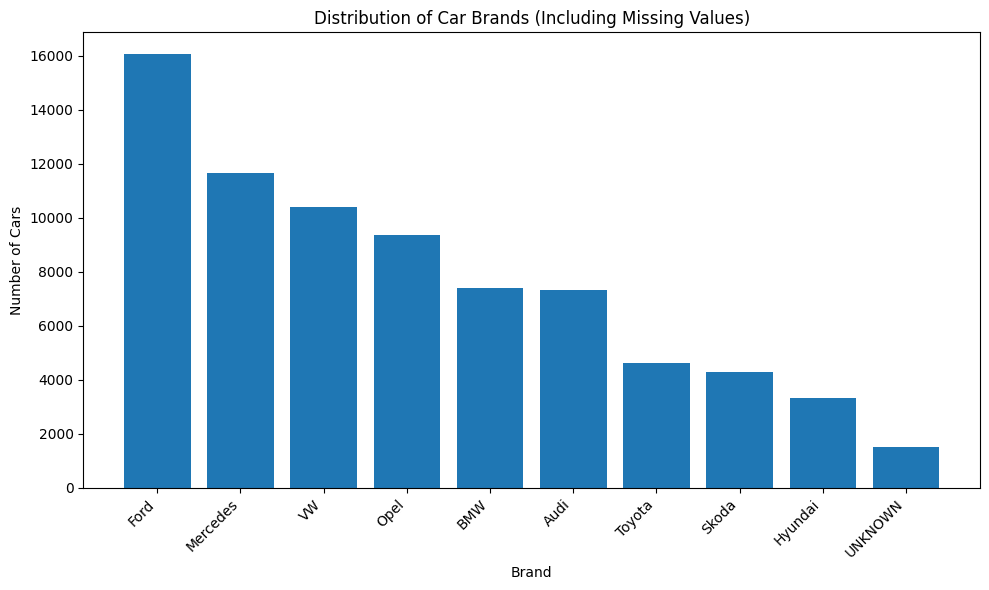

In [162]:
# =========================================
# Brand feature — Distribution bar plot (with NaN)
# =========================================

import matplotlib.pyplot as plt

# ---- Brand distribution (NaN included as category)
brand_counts = df["Brand"].fillna("UNKNOWN").value_counts()

plt.figure(figsize=(10, 6))
plt.bar(brand_counts.index, brand_counts.values)

plt.title("Distribution of Car Brands (Including Missing Values)")
plt.xlabel("Brand")
plt.ylabel("Number of Cars")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [163]:
from IPython.display import display, HTML

display(HTML("""
<div style="background-color:#e8f1ff; padding:12px; border-radius:8px; border-left:6px solid #1f77ff;">
<b>Brand — data quality issues and normalization strategy</b><br><br>

Approximately <b>1500 missing values (NaNs)</b> are present in the <b>Brand</b> feature,
along with several inconsistent and misspelled entries.<br><br>

To ensure a single, standardized brand name per vehicle, we apply a
<b>fuzzy string matching</b> strategy to correct invalid and inconsistent values.<br><br>

The helper function <b>HELPER_marca_correta()</b> evaluates each brand value
individually. Invalid entries (NaN or empty strings) are ignored, while valid
strings are converted to lowercase and compared against a predefined list of
valid brands using <b>RapidFuzz</b> (<code>process.extractOne()</code>).<br><br>

If the similarity score exceeds a predefined threshold, the value is replaced by
its standardized form; otherwise, it is left unchanged. This logic is applied to
the full dataset through the <b>fuzzy_marcas()</b> function.<br><br>

The matching strictness is controlled via the <b>threshold parameter</b>
(<code>threshold=50</code>): lower values allow more aggressive corrections,
while higher values restrict replacements to very similar strings.<br><br>

This process effectively normalizes the <b>Brand</b> feature, consolidating entries
such as <i>'Audi'</i>, <i>'Aud'</i>, <i>'udi'</i>, <i>'audi'</i>, <i>'AUD'</i> and
<i>'ud'</i> into the correct standardized brand name, <b>'Audi'</b>.
</div>
"""))


## **2.4 Model Feature**


In [164]:
# =========================================
# Model feature — Exploration and correction
# =========================================

from IPython.display import display, HTML

# ---- Unique models
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>Model — unique values</b>
</div>
"""))
display(df["model"].unique())

# ---- Number of unique models
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>Model — number of unique values</b>
</div>
"""))
display(len(df["model"].unique()))

# ---- Models grouped by brand (example)
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>Model — examples grouped by brand (Hyundai)</b>
</div>
"""))
grouped = df.groupby("Brand")["model"].value_counts()
display(grouped["Hyundai"])

# ---- Valid models dictionary
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>Model — normalization strategy</b><br>
Model names are standardized using brand-specific valid model lists and fuzzy matching.
</div>
"""))

from valid_models import valid_models


# ---- Helper: normalize model strings
def HELPER_normalize_models(df):
    df = df.copy()
    df["model"] = (
        df["model"]
        .astype(str)
        .str.upper()
        .str.replace("-", "", regex=False)
        .str.replace(r"\s+", "", regex=True)
        .replace(["", "NAN", "NONE"], None)
    )
    return df


# ---- Helper: hybrid similarity scorer
def HELPER_hybrid_scorer(a, b, **kwargs):
    lev = distance.Levenshtein.normalized_similarity(a, b)
    token = fuzz.token_sort_ratio(a, b) / 100
    return (0.7 * lev + 0.3 * token) * 100


# ---- Helper: correct single model
def HELPER_modelo_correto(model, brand, valid_models_dict, threshold):
    if not model or model.strip() == "":
        return None

    if not brand or brand not in valid_models_dict:
        return model

    valid_list = valid_models_dict[brand]
    result = process.extractOne(model, valid_list, scorer=HELPER_hybrid_scorer)

    if result is None:
        return model

    model_name, score, _ = result
    return model_name if score >= threshold else None


# ---- Dataset-level fuzzy correction
def fuzzy_modelos(df, valid_models_dict, threshold=30):
    df = HELPER_normalize_models(df)

    df["model"] = df.apply(
        lambda row: HELPER_modelo_correto(
            row["model"], row["Brand"], valid_models_dict, threshold
        ),
        axis=1
    )
    return df


# ---- Before correction
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>Model — before correction</b>
</div>
"""))
display(len(df["model"].unique()))
display(df[df["model"].isna()])


# ---- Apply correction
df = fuzzy_modelos(df, valid_models)

# ---- After correction
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>Model — after fuzzy correction</b>
</div>
"""))
display(df[df["model"].isna()])

unique_models_per_brand = df.groupby("Brand")["model"].nunique()
display(unique_models_per_brand)


# ---- Conclusion
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>Conclusion</b><br>
Model names were successfully standardized using brand-specific fuzzy matching,
significantly reducing noise and cardinality.
</div>
"""))


array([' Golf', ' Yaris', ' Q2', ' FIESTA', ' 2 Series', '3 Series',
       ' A3', ' Octavia', ' Passat', ' Focus', ' Insignia', ' A Clas',
       ' Q3', ' Fabia', ' A Class', ' Ka+', ' 3 Series', ' GLC Class',
       ' I30', ' C Class', ' Polo', ' E Class', ' C Clas', ' Q5', ' Up',
       ' Fiesta', ' C-HR', ' Mokka X', ' Corsa', ' Astra', ' TT',
       ' 5 Series', ' Aygo', ' 4 Series', ' SLK', ' Viva', ' T-Roc',
       'Focus', ' EcoSport', ' Tucson', ' EcoSpor', nan, ' X-CLASS',
       ' CL Class', ' IX20', ' i20', ' Rapid', ' a1', ' Auris', ' sharan',
       ' I20', ' Adam', ' X3', ' A8', ' GLS Class', ' B-MAX', ' A4',
       ' Kona', ' I10', ' A1', ' Mokka', ' fiesta', ' S-MAX', ' X2',
       ' Crossland X', ' Tiguan', ' A5', ' GLE Class', ' C CLASS',
       ' mokka x', ' Zafira', ' Ioniq', ' A6', ' Mondeo', ' Yeti Outdoor',
       ' X1', 'POLO', ' INSIGNIA', ' Scala', ' S Class', ' 1 Series',
       ' Kamiq', ' Kuga', ' Tourneo Connect', ' Q7', ' GLA Class',
       ' Arteon', ' 

736

,count
model,
Tucson,821
I10,671
I30,352
I20,307
Kona,213
Ioniq,185
Santa Fe,135
IX20,129
I40,78


736

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
30317,Ford,NaN,2019.0,9999,Manual,10000.0,Petrol,145.0,47.9,0.0,61.0,3.0,0.0
28739,Ford,NaN,2015.0,7099,Manual,74176.0,Diesel,NaN,NaN,1.5,84.0,2.0,NaN
63868,Opel,NaN,2016.0,8695,Manual,39460.0,Petrol,125.0,50.4,1.4,99.0,1.0,0.0
18304,Ford,NaN,2016.0,9632,Manual,18814.0,Petrol,20.0,62.8,1.0,74.0,NaN,0.0
65285,Opel,NaN,2016.0,6999,Manual,45367.0,Petrol,30.0,55.4,1.4,41.0,2.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
72991,VW,NaN,2018.0,17391,Manual,17987.0,Petrol,145.0,46.3,1.4,58.0,2.0,NaN
29299,Ford,NaN,2017.0,19289,anual,28492.0,Diesel,145.0,56.5,2.0,85.0,1.0,0.0
56250,Opel,NaN,2019.0,15495,Manual,3129.0,Petrol,145.0,39.2,1.4,49.0,0.0,NaN


,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
30317,Ford,None,2019.0,9999,Manual,10000.0,Petrol,145.0,47.9,0.0,61.0,3.0,0.0
28739,Ford,None,2015.0,7099,Manual,74176.0,Diesel,NaN,NaN,1.5,84.0,2.0,NaN
63868,Opel,None,2016.0,8695,Manual,39460.0,Petrol,125.0,50.4,1.4,99.0,1.0,0.0
18304,Ford,None,2016.0,9632,Manual,18814.0,Petrol,20.0,62.8,1.0,74.0,NaN,0.0
65285,Opel,None,2016.0,6999,Manual,45367.0,Petrol,30.0,55.4,1.4,41.0,2.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
72991,VW,None,2018.0,17391,Manual,17987.0,Petrol,145.0,46.3,1.4,58.0,2.0,NaN
29299,Ford,None,2017.0,19289,anual,28492.0,Diesel,145.0,56.5,2.0,85.0,1.0,0.0
56250,Opel,None,2019.0,15495,Manual,3129.0,Petrol,145.0,39.2,1.4,49.0,0.0,NaN


,model
Brand,
Audi,25
BMW,24
Ford,22
Hyundai,15
Mercedes,13
Opel,23
Skoda,12
Toyota,18
VW,25


## **2.5 Year Feature**


array([2016.        , 2019.        , 2018.        , 2014.        ,
       2017.        , 2020.        , 2013.        ,           nan,
       2015.        , 2023.36707842, 2011.        , 2012.        ,
       2023.1169636 , 2003.        , 2009.        , 2007.        ,
       2005.        , 2011.11118842, 2011.21085349, 2023.97731126,
       2004.        , 2010.        , 2010.56500919, 2008.        ,
       2024.12175905, 2006.        , 2023.60527574, 2023.38982198,
       2010.67696784, 2001.        , 2000.        , 2023.26798867,
       2010.26863473, 2010.37154646, 2002.        , 2022.69668507,
       2009.81675711, 2010.7464032 , 2012.69574039, 1996.        ,
       1998.        , 2022.87800554, 1970.        , 1999.        ,
       1997.        ])

,Brand,model,year,engineSize
carID,,,,
25881,Ford,ESCORT,1996.0,1.8
3908,Audi,A3,1998.0,1.8
62732,Opel,ZAFIRA,1970.0,NaN
13422,BMW,Z3,1999.0,1.9
36128,Mercedes,SLK,1998.0,2.3
51800,Toyota,YARIS,1999.0,1.3
34918,Mercedes,SCLASS,1997.0,3.2
52914,Toyota,LANDCRUISER,1998.0,4.2
35769,Mercedes,MCLASS,1970.0,0.0


,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
35263,Mercedes,CCLASS,<NA>,11295,Automatic,45000.0,Petrol,-56.193202,46.3,1.6,59.0,NaN,0.0
53282,Toyota,YARIS,<NA>,16995,Manual,1225.0,Petrol,145.000000,47.9,1.5,77.0,0.0,0.0
68423,VW,POLO,<NA>,10328,NaN,26941.0,Petrol,145.000000,60.1,1.2,97.0,4.0,0.0
49731,Skoda,OCTAVIA,<NA>,11990,Manual,35650.0,NaN,30.000000,55.4,1.4,68.0,3.0,0.0
38604,Mercedes,ECLASS,<NA>,34980,Semi-Auto,4196.0,diesel,145.000000,70.6,2.0,44.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
67270,VW,POLO,<NA>,6880,Semi-Auto,44551.0,etrol,145.000000,47.9,1.4,92.0,2.0,0.0
61087,Opel,None,<NA>,14295,Manual,14609.0,Petrol,145.000000,39.2,1.4,50.0,2.0,0.0
62592,Opel,ASTRA,<NA>,10295,Manual,10271.0,Petrol,145.000000,62.8,1.0,99.0,3.0,0.0


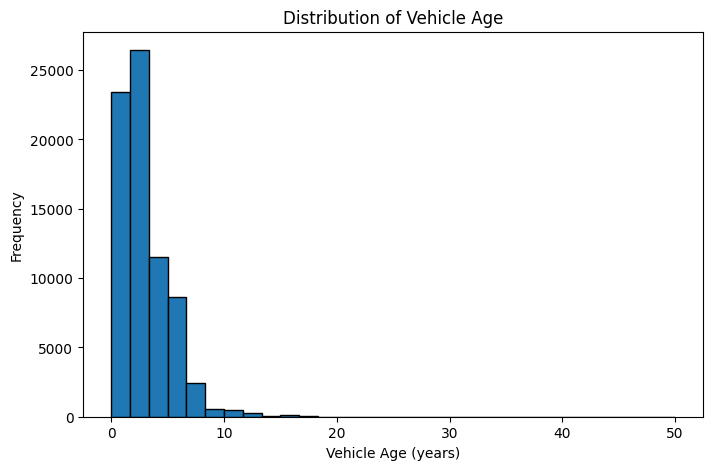

<IntegerArray>
[   4,    1,    2,    6,    3,    0,    7, <NA>,    5,    9,    8,   17,   11,
   13,   15,   16,   10,   12,   14,   19,   20,   18,   24,   22,   50,   21,
   23]
Length: 27, dtype: Int64

,Brand,model,year,price
carID,,,,
60156,Opel,AGILA,17,450
19562,Ford,FOCUS,17,495
23427,Ford,FOCUS,17,495
61005,Opel,CORSA,18,495
55950,Opel,CORSA,17,590


,Brand,model,year,price
carID,,,,
43994,Mercedes,ACLASS,1,140319
766,Audi,R8,0,145000
46012,Mercedes,SCLASS,9,149948
35340,Mercedes,GCLASS,0,154998
38485,Mercedes,GCLASS,0,159999


In [165]:
# =========================================
# Year feature — Exploration and preprocessing
# =========================================

from IPython.display import display, HTML
import matplotlib.pyplot as plt
import numpy as np

# ---- Inspect raw year values (manufacturing year)
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>Year — raw values (manufacturing year)</b><br>
Values represent the original manufacturing year before preprocessing.
</div>
"""))
display(df["year"].unique())


# ---- Identify suspicious manufacturing years (pre-transformation)
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>Year — suspicious manufacturing years</b><br>
Vehicles with implausibly old manufacturing years.
</div>
"""))
old_cars = df[df["year"] < 2000][["Brand", "model", "year", "engineSize"]]
display(old_cars)


# ---- Feature engineering: convert manufacturing year to vehicle age
def limpar_anos(df, max_year=2020):
    df = df.copy()

    # Convert manufacturing year to vehicle age
    df["year"] = max_year - df["year"]

    # Remove invalid ages (negative or unrealistically old)
    df.loc[(df["year"] < 0) | (df["year"] > 50), "year"] = np.nan

    df["year"] = np.floor(df["year"]).astype("Int64")
    return df


# ---- Apply transformation
df = limpar_anos(df, 2020)


# ---- Missing values after transformation
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>Year — missing values after transformation</b><br>
Missing values correspond to invalid or implausible vehicle ages.
</div>
"""))
display(df[df["year"].isna()])


# ---- Distribution of vehicle age (final)
plt.figure(figsize=(8, 5))
plt.hist(df["year"].dropna(), bins=30, edgecolor="black")
plt.title("Distribution of Vehicle Age")
plt.xlabel("Vehicle Age (years)")
plt.ylabel("Frequency")
plt.show()


# ---- Unique values after preprocessing (vehicle age)
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>Age of the car — unique values</b><br>
Values now represent vehicle age in years.
</div>
"""))
display(df["year"].unique())


# ---- Sanity check: cheapest vs most expensive vehicles
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>Vehicle age — price sanity check</b><br>
Inspecting whether vehicle age aligns with price extremes.
</div>
"""))

ordenado = df.sort_values("price", ascending=True)
baratos = ordenado[["Brand", "model", "year", "price"]].head(5)
caros = ordenado[["Brand", "model", "year", "price"]].tail(5)

display(baratos)
display(caros)


# ---- Conclusion
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>Conclusion</b><br>
The <b>year</b> feature was successfully transformed from manufacturing year into
<b>vehicle age</b>. Invalid and implausible values were removed, resulting in a clean,
low-cardinality numerical feature suitable for feature engineering, imputation,
and modeling.
</div>
"""))


In [166]:
df["year"].describe()


,year
count,74124.0
mean,2.93183
std,2.163122
min,0.0
25%,1.0
50%,3.0
75%,4.0
max,50.0


## **2.6 Transmission Feature**


In [167]:
# =========================================
# Transmission feature — Exploration and correction
# =========================================

from IPython.display import display, HTML
import numpy as np
import pandas as pd

# ---- Unique values
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>Transmission — unique values</b>
</div>
"""))
display(df["transmission"].unique())


# ---- Missing values
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>Transmission — missing values</b>
</div>
"""))
display(df[df["transmission"].isna()])


# ---- Helper: normalize transmission strings
def HELPER_normalize_transmission(df):
    df = df.copy()
    df["transmission"] = (
        df["transmission"]
        .astype(str)
        .str.strip()
        .str.upper()
        .replace(["", "NAN", "NONE"], np.nan)
    )
    return df


# ---- Helper: correct single transmission entry
def HELPER_transmissao_correta(transm, valid_list, threshold):
    if pd.isna(transm):
        return np.nan

    if transm in valid_list:
        return transm

    result = process.extractOne(transm, valid_list, scorer=fuzz.token_sort_ratio)
    if result is None:
        return np.nan

    match_name, score, _ = result
    return match_name if score >= threshold else np.nan


# ---- Dataset-level fuzzy correction
def fuzzy_transmissao(df, threshold=60):
    df = df.copy()
    df = HELPER_normalize_transmission(df)

    valid_list = ["MANUAL", "AUTOMATIC", "SEMI-AUTO", "OTHER", "UNKNOWN"]

    df["transmission"] = df["transmission"].apply(
        lambda x: HELPER_transmissao_correta(x, valid_list, threshold)
    )
    return df


# ---- Apply correction
df = fuzzy_transmissao(df)


# ---- Results after correction
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>Transmission — results after correction</b>
</div>
"""))
display(df[df["transmission"].isna()])
display(df["transmission"].unique())


# ---- Conclusion
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>Conclusion</b><br>
Transmission values were successfully standardized into a small, well-defined
set of categories, reducing noise and improving suitability for categorical encoding.
</div>
"""))


array(['Semi-Auto', 'Manual', 'anual', 'Semi-Aut', 'Automatic', 'manual',
       nan, 'unknown', 'Manua', 'AUTOMATIC', 'MANUAL', 'semi-auto',
       ' Manual ', 'automatic', 'emi-Auto', 'SEMI-AUTO', 'SEMI-AUT',
       'Automati', 'ANUAL', 'utomatic', 'unknow', 'EMI-AUTO', 'manua',
       'anua', 'emi-Aut', 'MANUA', 'emi-auto', 'UTOMATIC', ' manual ',
       ' MANUAL ', 'UNKNOWN', 'nknown', 'automati', 'Other', 'semi-aut',
       ' Manual', 'AUTOMATI', 'utomati', 'Manual ', 'manual ', 'nknow'],
      dtype=object)

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
35317,Mercedes,CCLASS,1,26176,NaN,9463.0,Petrol,NaN,NaN,1.5,87.0,1.0,0.0
35376,Mercedes,CCLASS,5,16998,NaN,43883.0,Diesel,125.0,60.1,2.1,54.0,0.0,0.0
64396,Opel,ASTRA,5,6995,NaN,NaN,Diesel,0.0,78.5,1.6,61.0,2.0,0.0
68423,VW,POLO,<NA>,10328,NaN,26941.0,Petrol,145.0,60.1,1.2,97.0,4.0,0.0
47887,Skoda,FABIA,0,11990,NaN,835.0,Petrol,145.0,47.1,1.0,55.0,3.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2368,Audi,Q2,1,19990,NaN,1500.0,Petrol,145.0,47.1,1.0,92.0,2.0,0.0
12874,BMW,4SERIES,1,29995,NaN,999.0,Diesel,145.0,53.3,3.0,64.0,0.0,0.0
1016,Audi,Q5,4,22995,NaN,28000.0,Diesel,200.0,NaN,2.0,42.0,4.0,0.0


,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
35317,Mercedes,CCLASS,1,26176,NaN,9463.0,Petrol,NaN,NaN,1.5,87.0,1.0,0.0
35376,Mercedes,CCLASS,5,16998,NaN,43883.0,Diesel,125.0,60.1,2.1,54.0,0.0,0.0
64396,Opel,ASTRA,5,6995,NaN,NaN,Diesel,0.0,78.5,1.6,61.0,2.0,0.0
68423,VW,POLO,<NA>,10328,NaN,26941.0,Petrol,145.0,60.1,1.2,97.0,4.0,0.0
47887,Skoda,FABIA,0,11990,NaN,835.0,Petrol,145.0,47.1,1.0,55.0,3.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2368,Audi,Q2,1,19990,NaN,1500.0,Petrol,145.0,47.1,1.0,92.0,2.0,0.0
12874,BMW,4SERIES,1,29995,NaN,999.0,Diesel,145.0,53.3,3.0,64.0,0.0,0.0
1016,Audi,Q5,4,22995,NaN,28000.0,Diesel,200.0,NaN,2.0,42.0,4.0,0.0


array(['SEMI-AUTO', 'MANUAL', 'AUTOMATIC', nan, 'UNKNOWN', 'OTHER'],
      dtype=object)

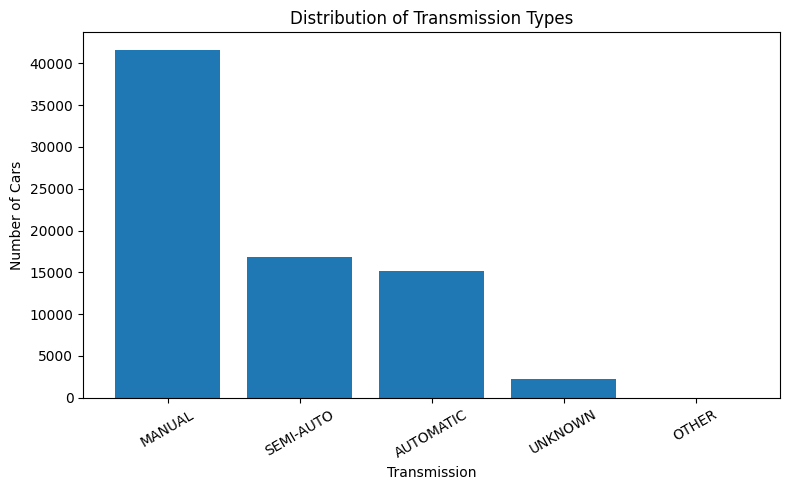

In [168]:
# =========================================
# Transmission feature — Distribution bar plot
# =========================================

import matplotlib.pyplot as plt

# ---- Transmission distribution (NaN included)
transmission_counts = (
    df["transmission"]
    .fillna("UNKNOWN")
    .value_counts()
)

plt.figure(figsize=(8, 5))
plt.bar(transmission_counts.index, transmission_counts.values)

plt.title("Distribution of Transmission Types")
plt.xlabel("Transmission")
plt.ylabel("Number of Cars")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


## **2.7 `mileage` feature**


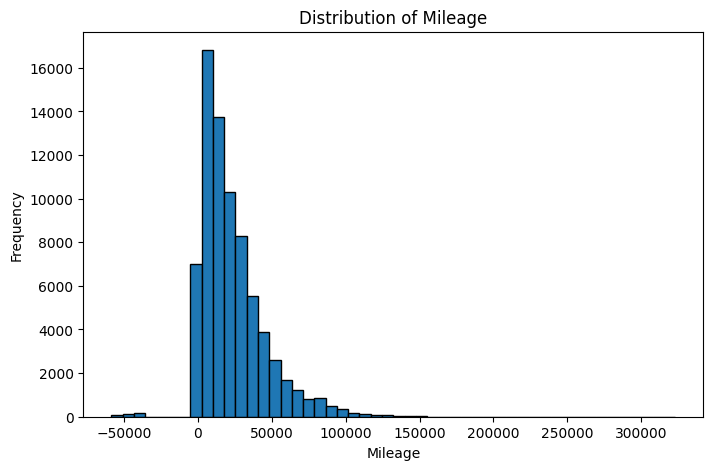

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
64396,Opel,ASTRA,5,6995,NaN,NaN,Diesel,0.000000,78.5,1.6,61.0,2.0,0.0
41441,Mercedes,ACLASS,3,13500,MANUAL,NaN,Diesel,150.000000,72.4,1.5,32.0,2.0,0.0
22269,Ford,FIESTA,3,8930,NaN,NaN,Petrol,145.000000,54.3,1.2,97.0,0.0,0.0
6409,Audi,A1,4,10999,MANUAL,NaN,Diesel,0.000000,76.3,1.6,97.0,3.0,0.0
7725,BMW,X2,1,23633,MANUAL,NaN,Diesel,145.000000,53.3,2.0,97.0,2.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
33828,Hyundai,TUCSON,1,18390,MANUAL,NaN,Petrol,145.000000,34.9,1.6,86.0,4.0,0.0
55680,Toyota,CHR,3,20700,AUTOMATIC,NaN,Hybrid,135.000000,74.3,1.8,86.0,0.0,0.0
39353,Mercedes,GLCLASS,1,36490,SEMI-AUTO,NaN,Diesel,145.000000,40.9,2.0,36.0,3.0,0.0


,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
70615,VW,TIGUAN,0,25000,MANUAL,-48190.655673,Petrol,145.0,38.2,1.5,89.0,3.0,0.0
43529,Mercedes,CCLASS,1,25780,SEMI-AUTO,-50755.210230,Diesel,NaN,NaN,2.0,72.0,3.0,0.0
71090,VW,GOLF,2,14995,MANUAL,-48190.655673,Diesel,150.0,57.7,1.6,83.0,2.0,0.0
7845,BMW,3SERIES,1,23498,SEMI-AUTO,-58540.574478,Diesel,145.0,54.3,2.0,38.0,NaN,0.0
24999,Ford,FIESTA,3,8895,MANUAL,-42650.453719,Petrol,125.0,54.3,1.2,45.0,4.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
56373,Opel,None,2,8514,MANUAL,-42707.564215,Petrol,150.0,55.4,1.4,49.0,1.0,NaN
45765,Mercedes,GLCLASS,0,54995,AUTOMATIC,-50755.210230,Diesel,150.0,32.8,3.0,69.0,4.0,0.0
38413,Mercedes,SLK,5,17900,AUTOMATIC,-50755.210230,Diesel,150.0,56.5,2.1,40.0,3.0,0.0


,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
70615,VW,TIGUAN,0,25000,MANUAL,NaN,Petrol,145.0,38.2,1.5,89.0,3.0,0.0


,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,


,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
64396,Opel,ASTRA,5,6995,NaN,NaN,Diesel,0.000000,78.5,1.6,61.0,2.0,0.0
41441,Mercedes,ACLASS,3,13500,MANUAL,NaN,Diesel,150.000000,72.4,1.5,32.0,2.0,0.0
22269,Ford,FIESTA,3,8930,NaN,NaN,Petrol,145.000000,54.3,1.2,97.0,0.0,0.0
6409,Audi,A1,4,10999,MANUAL,NaN,Diesel,0.000000,76.3,1.6,97.0,3.0,0.0
7725,BMW,X2,1,23633,MANUAL,NaN,Diesel,145.000000,53.3,2.0,97.0,2.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
39353,Mercedes,GLCLASS,1,36490,SEMI-AUTO,NaN,Diesel,145.000000,40.9,2.0,36.0,3.0,0.0
9474,BMW,3SERIES,4,14000,MANUAL,NaN,Diese,316.487189,62.8,2.0,77.0,4.0,0.0
55820,Toyota,AYGO,1,8491,MANUAL,NaN,Petrol,145.000000,56.5,1.0,56.0,0.0,0.0


In [169]:
# =========================================
# Mileage feature — Exploration
# =========================================

from IPython.display import display, HTML
import matplotlib.pyplot as plt
import numpy as np

# ---- Distribution of mileage (raw)
plt.figure(figsize=(8, 5))
plt.hist(df["mileage"].dropna(), bins=50, edgecolor="black")
plt.title("Distribution of Mileage")
plt.xlabel("Mileage")
plt.ylabel("Frequency")
plt.show()


# ---- Missing values
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>Mileage — missing values</b>
</div>
"""))
display(df[df["mileage"].isna()])


# ---- Invalid negative values
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>Mileage — invalid negative values</b>
</div>
"""))
display(df[df["mileage"] < 0])


# ---- Helper: assign impossible values to NaN
def impossible_to_nan(df, col, val=0, lower_upper="lower"):
    df = df.copy()

    if lower_upper == "lower":
        df.loc[df[col] < val, col] = np.nan
    else:
        df.loc[df[col] > val, col] = np.nan

    return df


# ---- Apply correction
df = impossible_to_nan(df, "mileage")


# ---- Sanity check (example row)
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>Mileage — sanity check</b>
</div>
"""))
display(df.loc[[70615]])


# ---- Post-cleaning checks
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>Mileage — after preprocessing</b>
</div>
"""))
display(df[df["mileage"] < 0])
display(df[df["mileage"].isna()])


# ---- Conclusion
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>Conclusion</b><br>
Negative mileage values were identified as invalid and converted to <b>NaN</b>.
The <b>mileage</b> feature is now numerically consistent and ready for imputation
and scaling within the machine learning pipeline.
</div>
"""))


## **2.8 fuelType feature**


array(['Petrol', 'Diesel', 'etrol', 'Hybrid', 'diesel', 'iesel', nan,
       'petrol', 'PETROL', 'Diese', 'Petro', 'DIESEL', 'petro', 'HYBRID',
       'ybri', 'Other', 'DIESE', 'Hybri', 'ETROL', 'ybrid', 'PETRO',
       'hybrid', 'IESEL', 'Electric', 'ther', 'iese', 'etro', 'ETRO',
       'diese', 'Othe', 'YBRID', 'HYBRI', 'OTHER', 'other', 'IESE'],
      dtype=object)

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
831,Audi,A8,3,38995,AUTOMATIC,3338.0,NaN,145.0,NaN,3.0,84.000000,0.000000,0.0
49731,Skoda,OCTAVIA,<NA>,11990,MANUAL,35650.0,NaN,30.0,55.4,1.4,68.000000,3.000000,0.0
1272,Audi,Q7,3,53990,SEMI-AUTO,30427.0,NaN,145.0,39.2,4.0,78.000000,1.000000,0.0
36753,Mercedes,SCLASS,3,18990,AUTOMATIC,21490.0,NaN,145.0,70.6,2.1,84.000000,6.258371,0.0
53403,Toyota,AYGO,4,7995,MANUAL,25300.0,NaN,0.0,69.0,1.0,125.594308,1.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
48354,Skoda,OCTAVIA,5,8599,MANUAL,57718.0,NaN,0.0,74.3,1.6,74.000000,3.000000,0.0
30306,Ford,FIESTA,3,8499,MANUAL,18227.0,NaN,0.0,65.7,1.0,99.000000,4.000000,0.0
30535,Ford,FIESTA,4,8990,MANUAL,46000.0,NaN,0.0,65.7,1.0,88.000000,2.000000,0.0


,count
fuelType,
Petrol,37995
Diesel,28474
Hybrid,2043
PETROL,795
etrol,794
Petro,785
petrol,746
iesel,603
diesel,599


array(['PETROL', 'DIESEL', 'HYBRID', nan, 'OTHER', 'ELECTRIC'],
      dtype=object)

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
831,Audi,A8,3,38995,AUTOMATIC,3338.0,NaN,145.0,NaN,3.0,84.000000,0.000000,0.0
49731,Skoda,OCTAVIA,<NA>,11990,MANUAL,35650.0,NaN,30.0,55.4,1.4,68.000000,3.000000,0.0
1272,Audi,Q7,3,53990,SEMI-AUTO,30427.0,NaN,145.0,39.2,4.0,78.000000,1.000000,0.0
36753,Mercedes,SCLASS,3,18990,AUTOMATIC,21490.0,NaN,145.0,70.6,2.1,84.000000,6.258371,0.0
53403,Toyota,AYGO,4,7995,MANUAL,25300.0,NaN,0.0,69.0,1.0,125.594308,1.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
48354,Skoda,OCTAVIA,5,8599,MANUAL,57718.0,NaN,0.0,74.3,1.6,74.000000,3.000000,0.0
30306,Ford,FIESTA,3,8499,MANUAL,18227.0,NaN,0.0,65.7,1.0,99.000000,4.000000,0.0
30535,Ford,FIESTA,4,8990,MANUAL,46000.0,NaN,0.0,65.7,1.0,88.000000,2.000000,0.0


,count
fuelType,
PETROL,41181
DIESEL,30885
HYBRID,2225
OTHER,167
ELECTRIC,4


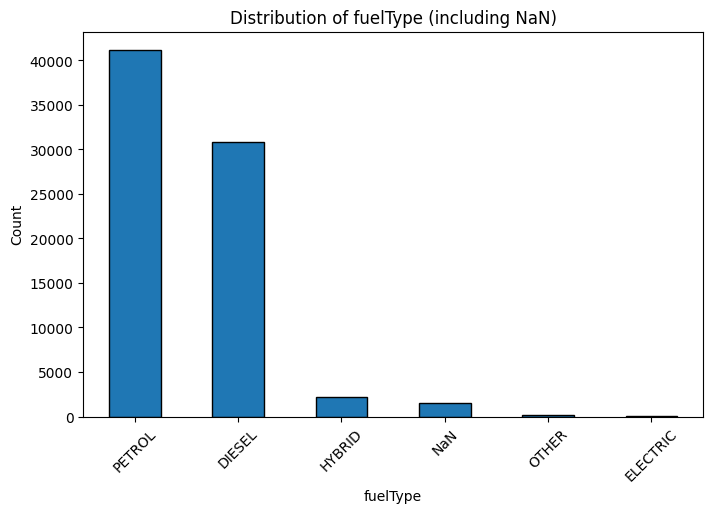

In [170]:
# =========================================
# FuelType feature — Exploration and preprocessing
# =========================================

from IPython.display import display, HTML
import numpy as np
import matplotlib.pyplot as plt

# ---- Unique values
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>fuelType — unique values</b>
</div>
"""))
display(df["fuelType"].unique())


# ---- Missing values
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>fuelType — missing values</b>
</div>
"""))
display(df[df["fuelType"].isna()])


# ---- Value counts
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>fuelType — value counts</b>
</div>
"""))
display(df["fuelType"].value_counts())


# ---- Helper: normalize fuel type strings
def HELPER_normalize_fueltype(df):
    df = df.copy()
    df["fuelType"] = (
        df["fuelType"]
        .astype(str)
        .str.strip()
        .str.upper()
        .replace(["", "NAN", "NONE"], np.nan)
    )
    return df


# ---- Helper: correct single fuel type using fuzzy matching
def HELPER_fuel_correto(fuel, valid_list, threshold):
    if pd.isna(fuel):
        return np.nan

    if fuel in valid_list:
        return fuel

    result = process.extractOne(fuel, valid_list, scorer=fuzz.token_sort_ratio)
    if result is None:
        return np.nan

    match_name, score, _ = result
    return match_name if score >= threshold else np.nan


# ---- Dataset-level fuzzy correction
def fuzzy_fuel(df, threshold=60):
    df = HELPER_normalize_fueltype(df)
    valid_list = ["PETROL", "DIESEL", "HYBRID", "OTHER", "ELECTRIC"]

    df["fuelType"] = df["fuelType"].apply(
        lambda x: HELPER_fuel_correto(x, valid_list, threshold)
    )
    return df


# ---- Apply correction
df = fuzzy_fuel(df)


# ---- Results after preprocessing
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>fuelType — after preprocessing</b>
</div>
"""))
display(df["fuelType"].unique())
display(df[df["fuelType"].isna()])
display(df["fuelType"].value_counts())


# ---- Bar plot (including NaN)
fuel_counts = df["fuelType"].fillna("NaN").value_counts()

plt.figure(figsize=(8, 5))
fuel_counts.plot(kind="bar", edgecolor="black")
plt.title("Distribution of fuelType (including NaN)")
plt.xlabel("fuelType")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()


# ---- Conclusion
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>Conclusion</b><br>
The <b>fuelType</b> feature was standardized using fuzzy string matching.
The bar plot confirms a small, well-defined set of fuel categories, with
remaining uncertain cases explicitly represented as <b>NaN</b>.
</div>
"""))


## **2.9 tax feature**

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
55065,Toyota,CHR,3,15490,AUTOMATIC,59000.0,HYBRID,0.0,74.3,1.8,95.0,2.0,0.0
64396,Opel,ASTRA,5,6995,NaN,NaN,DIESEL,0.0,78.5,1.6,61.0,2.0,0.0
54783,Toyota,YARIS,6,10490,AUTOMATIC,34528.0,HYBRID,0.0,80.7,1.5,79.0,1.0,0.0
47148,Skoda,RAPID,4,7991,MANUAL,33395.0,DIESEL,0.0,67.3,1.6,NaN,3.0,0.0
19051,Ford,FIESTA,7,6500,MANUAL,43181.0,PETROL,0.0,65.7,1.0,88.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
54268,Toyota,AYGO,3,6620,MANUAL,10266.0,PETROL,0.0,69.0,1.0,51.0,0.0,0.0
52992,Toyota,AYGO,4,8550,MANUAL,20680.0,PETROL,0.0,69.0,1.0,66.0,2.0,0.0
30535,Ford,FIESTA,4,8990,MANUAL,46000.0,NaN,0.0,65.7,1.0,88.0,2.0,0.0


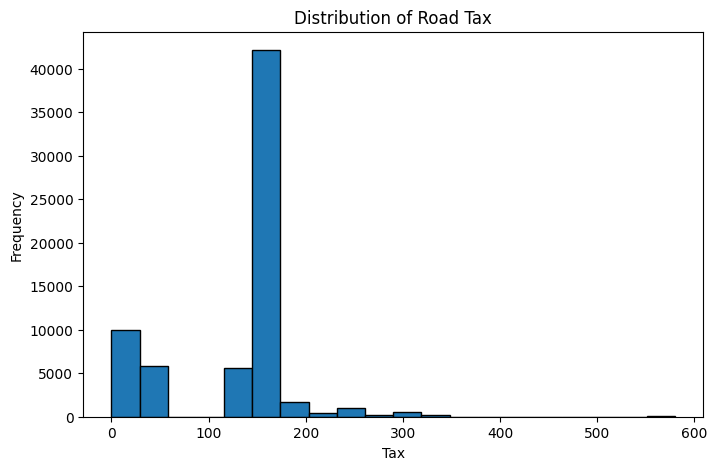

,count
year,
4,1675
3,1046
5,827
6,391
7,221
8,29
9,20
10,8
11,5


In [171]:
# =========================================
# Tax feature — Exploration and preprocessing
# =========================================

from IPython.display import display, HTML
import matplotlib.pyplot as plt
import numpy as np

# ---- Zero tax values
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>Tax — zero values</b>
</div>
"""))
display(df[df["tax"] == 0])


# ---- Helper: assign impossible values to NaN
def impossible_to_nan(df, col, val=0, lower_upper="lower"):
    df = df.copy()

    if lower_upper == "lower":
        df.loc[df[col] < val, col] = np.nan
    else:
        df.loc[df[col] > val, col] = np.nan

    return df


# ---- Apply correction (negative values → NaN)
df = impossible_to_nan(df, "tax")


# ---- Distribution after preprocessing
plt.figure(figsize=(8, 5))
plt.hist(df["tax"].dropna(), bins=20, edgecolor="black")
plt.title("Distribution of Road Tax")
plt.xlabel("Tax")
plt.ylabel("Frequency")
plt.show()


# ---- Interpretation of zero-tax vehicles
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>Tax — interpretation of zero values</b><br>
In the UK, road tax cannot be negative. Vehicles with <b>tax = 0</b> typically
correspond to newer, low-emission or electric vehicles.
</div>
"""))

g = df[df["tax"] == 0]
display(g["year"].value_counts())


# ---- Conclusion
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>Conclusion</b><br>
Negative road tax values were treated as invalid and converted to <b>NaN</b>.
Zero-tax vehicles were retained, as they represent valid cases under UK tax
regulations. The <b>tax</b> feature is now consistent and ready for modeling.
</div>
"""))


## **2.10 `mpg feature`**

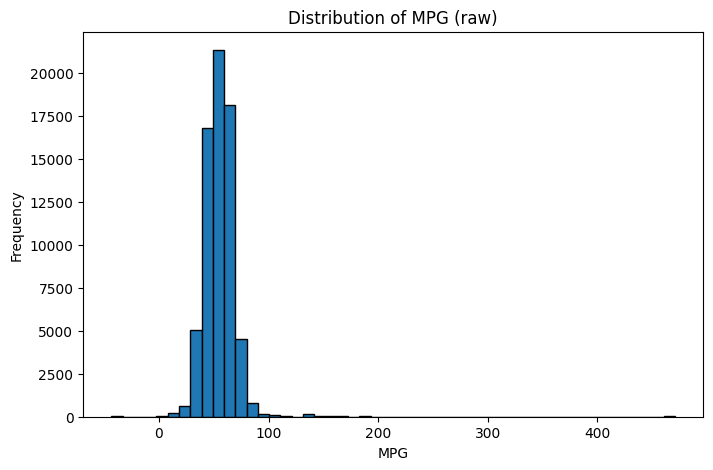

,count
fuelType,
HYBRID,357
DIESEL,63
PETROL,40
OTHER,32
ELECTRIC,2


,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
20142,Ford,FOCUS,3,18997,MANUAL,20112.0,PETROL,NaN,NaN,2.0,40.0,4.0,0.0
39796,Mercedes,CCLASS,1,31299,SEMI-AUTO,1000.0,DIESEL,NaN,NaN,2.0,33.0,4.0,0.0
35317,Mercedes,CCLASS,1,26176,NaN,9463.0,PETROL,NaN,NaN,1.5,87.0,1.0,0.0
35004,Mercedes,CCLASS,4,21499,AUTOMATIC,26741.0,DIESEL,NaN,NaN,2.1,80.0,1.0,0.0
19811,Ford,FOCUS,1,17990,AUTOMATIC,3289.0,DIESEL,NaN,NaN,1.5,38.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
24300,Ford,FOCUS,3,17000,MANUAL,26041.0,DIESEL,NaN,NaN,2.0,39.0,3.0,0.0
1016,Audi,Q5,4,22995,NaN,28000.0,DIESEL,200.0,NaN,2.0,42.0,4.0,0.0
40757,Mercedes,CCLASS,1,28980,AUTOMATIC,8501.0,DIESEL,NaN,NaN,2.0,97.0,3.0,0.0


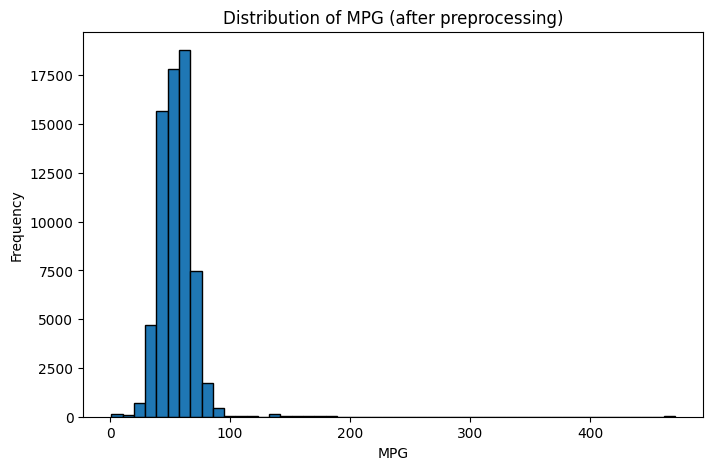

,count
fuelType,
HYBRID,357
DIESEL,63
PETROL,40
OTHER,32
ELECTRIC,2


,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
20142,Ford,FOCUS,3,18997,MANUAL,20112.0,PETROL,NaN,NaN,2.0,40.0,4.0,0.0
39796,Mercedes,CCLASS,1,31299,SEMI-AUTO,1000.0,DIESEL,NaN,NaN,2.0,33.0,4.0,0.0
35317,Mercedes,CCLASS,1,26176,NaN,9463.0,PETROL,NaN,NaN,1.5,87.0,1.0,0.0
35004,Mercedes,CCLASS,4,21499,AUTOMATIC,26741.0,DIESEL,NaN,NaN,2.1,80.0,1.0,0.0
19811,Ford,FOCUS,1,17990,AUTOMATIC,3289.0,DIESEL,NaN,NaN,1.5,38.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
24300,Ford,FOCUS,3,17000,MANUAL,26041.0,DIESEL,NaN,NaN,2.0,39.0,3.0,0.0
1016,Audi,Q5,4,22995,NaN,28000.0,DIESEL,200.0,NaN,2.0,42.0,4.0,0.0
40757,Mercedes,CCLASS,1,28980,AUTOMATIC,8501.0,DIESEL,NaN,NaN,2.0,97.0,3.0,0.0


In [172]:
# =========================================
# MPG feature — Exploration and preprocessing
# =========================================

from IPython.display import display, HTML
import matplotlib.pyplot as plt
import numpy as np

# ---- Distribution of mpg (raw)
plt.figure(figsize=(8, 5))
plt.hist(df["mpg"].dropna(), bins=50, edgecolor="black")
plt.title("Distribution of MPG (raw)")
plt.xlabel("MPG")
plt.ylabel("Frequency")
plt.show()


# ---- Interpretation
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>MPG — domain constraints</b><br>
Miles per gallon cannot be negative. Negative values are therefore considered
invalid and will be set to <b>NaN</b>.
</div>
"""))


# ---- High mpg inspection
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>MPG — unusually high values</b><br>
Vehicles with very high MPG values are inspected by fuel type.
</div>
"""))
display(df[df["mpg"] >= 100]["fuelType"].value_counts())


# ---- Missing values (before)
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>MPG — missing values (before)</b>
</div>
"""))
display(df[df["mpg"].isna()])


# ---- Apply correction (negative values → NaN)
df = impossible_to_nan(df, "mpg")


# ---- Distribution after preprocessing
plt.figure(figsize=(8, 5))
plt.hist(df["mpg"].dropna(), bins=50, edgecolor="black")
plt.title("Distribution of MPG (after preprocessing)")
plt.xlabel("MPG")
plt.ylabel("Frequency")
plt.show()


# ---- High mpg inspection (after)
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>MPG — high values after preprocessing</b>
</div>
"""))
display(df[df["mpg"] >= 100]["fuelType"].value_counts())


# ---- Missing values (after)
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>MPG — missing values (after)</b>
</div>
"""))
display(df[df["mpg"].isna()])


# ---- Conclusion
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>Conclusion</b><br>
Negative MPG values were identified as invalid and converted to <b>NaN</b>.
Very high MPG values were retained, as they are consistent with hybrid and
electric vehicles. The <b>mpg</b> feature is now clean and suitable for
imputation and scaling within the machine learning pipeline.
</div>
"""))


## **2.11 engineSize feature**

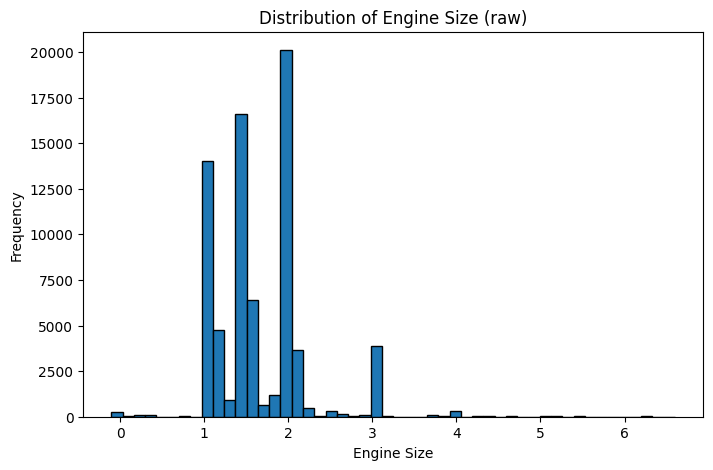

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
61006,Opel,CORSA,1,9995,MANUAL,4366.0,PETROL,150.0,43.5,0.739534,66.0,3.0,0.0
30317,Ford,None,1,9999,MANUAL,10000.0,PETROL,145.0,47.9,0.000000,61.0,3.0,0.0
24113,Ford,KUGA,<NA>,14950,MANUAL,13411.0,DIESEL,125.0,60.1,-0.103493,83.0,1.0,0.0
3840,Audi,None,1,21262,MANUAL,4868.0,DIESEL,145.0,49.6,0.154529,58.0,2.0,0.0
21935,Ford,KA,2,8444,MANUAL,17000.0,PETROL,145.0,57.7,0.000000,51.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
46732,Skoda,OCTAVIA,2,11290,MANUAL,20047.0,PETROL,145.0,58.9,0.191462,98.0,0.0,0.0
38494,Mercedes,GLCLASS,4,19498,SEMI-AUTO,27846.0,DIESEL,125.0,56.5,0.307074,89.0,4.0,0.0
59040,Opel,GRANDLANDX,1,17289,MANUAL,14421.0,DIESEL,145.0,56.5,0.739534,74.0,0.0,0.0


,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
48622,Skoda,FABIA,1,13295,AUTOMATIC,14378.0,PETROL,145.0,60.1,NaN,59.0,1.0,0.0
38898,Mercedes,GLCLASS,3,28995,AUTOMATIC,30808.0,DIESEL,150.0,56.5,NaN,60.0,1.0,0.0
54844,Toyota,AYGO,3,7299,MANUAL,48238.0,PETROL,0.0,68.9,NaN,80.0,0.0,0.0
57086,Opel,INSIGNIA,3,7695,MANUAL,51840.0,DIESEL,0.0,74.3,NaN,76.0,2.0,0.0
70418,NaN,GOLF,4,16898,MANUAL,24180.0,DIESEL,20.0,67.3,NaN,83.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
68840,VW,POLO,1,14999,MANUAL,4436.0,PETROL,150.0,52.3,NaN,98.0,2.0,0.0
61373,Opel,ASTRA,3,10800,MANUAL,19025.0,PETROL,125.0,50.4,NaN,36.0,0.0,0.0
68148,VW,GOLF,0,20769,MANUAL,1116.0,PETROL,145.0,49.6,NaN,86.0,4.0,0.0


,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
38980,Mercedes,CCLASS,7,23000,SEMI-AUTO,43442.000000,PETROL,NaN,NaN,6.2,76.0,0.0,0.0
46372,Mercedes,CCLASS,7,22995,SEMI-AUTO,49964.000000,PETROL,NaN,23.0,6.2,78.0,3.0,0.0
9197,BMW,7SERIES,3,57000,AUTOMATIC,11297.000000,PETROL,145.000000,22.1,6.6,68.0,1.0,0.0
42286,Mercedes,CCLASS,6,26998,SEMI-AUTO,24175.000000,PETROL,NaN,NaN,6.2,93.0,2.0,0.0
39900,Mercedes,CCLASS,6,28990,SEMI-AUTO,19562.000000,PETROL,NaN,NaN,6.2,83.0,0.0,0.0
39852,Mercedes,SCLASS,10,26990,AUTOMATIC,38000.000000,PETROL,570.000000,19.5,6.2,76.0,4.0,0.0
35612,Mercedes,CCLASS,7,23990,AUTOMATIC,NaN,PETROL,570.000000,23.5,6.2,44.0,2.0,0.0
36196,Mercedes,CCLASS,6,25885,SEMI-AUTO,86705.854885,PETROL,NaN,NaN,6.2,31.0,0.0,0.0
35538,NaN,CCLASS,<NA>,22995,SEMI-AUTO,49964.000000,PETROL,326.028233,NaN,6.2,58.0,3.0,0.0


,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
48622,Skoda,FABIA,1,13295,AUTOMATIC,14378.0,PETROL,145.0,60.1,NaN,59.0,1.0,0.0
38898,Mercedes,GLCLASS,3,28995,AUTOMATIC,30808.0,DIESEL,150.0,56.5,NaN,60.0,1.0,0.0
30317,Ford,None,1,9999,MANUAL,10000.0,PETROL,145.0,47.9,NaN,61.0,3.0,0.0
54844,Toyota,AYGO,3,7299,MANUAL,48238.0,PETROL,0.0,68.9,NaN,80.0,0.0,0.0
57086,Opel,INSIGNIA,3,7695,MANUAL,51840.0,DIESEL,0.0,74.3,NaN,76.0,2.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
70592,VW,CADDYMAXI,5,9995,SEMI-AUTO,66000.0,DIESEL,200.0,48.7,NaN,34.0,3.0,0.0
68148,VW,GOLF,0,20769,MANUAL,1116.0,PETROL,145.0,49.6,NaN,86.0,4.0,0.0
10627,BMW,3SERIES,0,24990,SEMI-AUTO,22.0,DIESEL,150.0,54.3,NaN,90.0,1.0,0.0


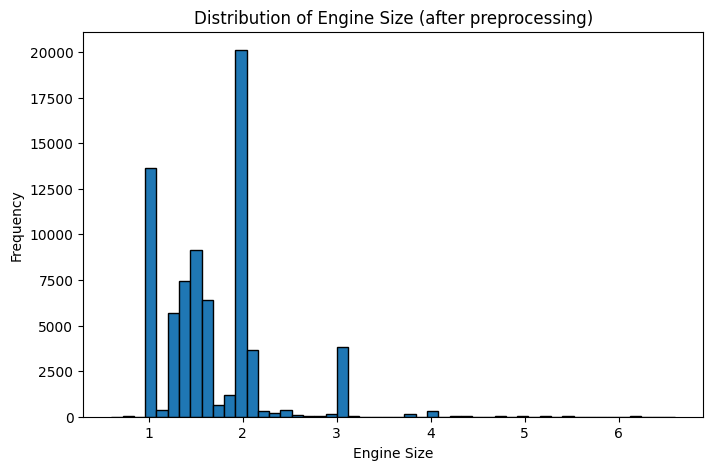

In [173]:
# =========================================
# EngineSize feature — Exploration
# =========================================

from IPython.display import display, HTML
import matplotlib.pyplot as plt
import numpy as np

# ---- Distribution of engineSize (raw)
plt.figure(figsize=(8, 5))
plt.hist(df["engineSize"].dropna(), bins=50, edgecolor="black")
plt.title("Distribution of Engine Size (raw)")
plt.xlabel("Engine Size")
plt.ylabel("Frequency")
plt.show()


# ---- Suspiciously small engine sizes
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>EngineSize — values below 1.0</b>
</div>
"""))
display(df[df["engineSize"] < 1])


# ---- Missing values
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>EngineSize — missing values</b>
</div>
"""))
display(df[df["engineSize"].isna()])


# ---- Extremely large engine sizes
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>EngineSize — values above 6.0</b>
</div>
"""))
display(df[df["engineSize"] > 6])


# ---- Apply domain-based correction
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>EngineSize — domain constraint</b><br>
The smallest realistic engine sizes are approximately between <b>0.6</b> and
<b>1.0</b> liters. Values below this threshold are treated as invalid inputs and
set to <b>NaN</b>.
</div>
"""))

df = impossible_to_nan(df, "engineSize", 0.6)


# ---- Missing values after preprocessing
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>EngineSize — missing values after preprocessing</b>
</div>
"""))
display(df[df["engineSize"].isna()])


# ---- Distribution after preprocessing
plt.figure(figsize=(8, 5))
plt.hist(df["engineSize"].dropna(), bins=50, edgecolor="black")
plt.title("Distribution of Engine Size (after preprocessing)")
plt.xlabel("Engine Size")
plt.ylabel("Frequency")
plt.show()


# ---- Conclusion
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>Conclusion</b><br>
Unrealistic engine size values were identified using domain knowledge and
converted to <b>NaN</b>. After preprocessing, the <b>engineSize</b> feature
exhibits a coherent distribution and is suitable for numerical imputation
and scaling within the machine learning pipeline.
</div>
"""))


## **2.12 Preprocessing paintQuality%**

In [174]:
# =========================================
# paintQuality% feature — Removal
# =========================================

from IPython.display import display, HTML

# ---- Feature removal rationale
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>paintQuality% — feature removal</b><br>
This feature is removed in accordance with the assignment instructions.
The model should only rely on information available to a customer without
requiring a mechanical inspection.
</div>
"""))


# ---- Helper: drop paintQuality%
def drop_paint(df):
    df = df.copy()
    df = df.drop(columns=["paintQuality%"], errors="ignore")
    return df


# ---- Apply removal
df = drop_paint(df)


# ---- Sanity check
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>paintQuality% — verification</b><br>
The feature has been successfully removed from the dataset.
</div>
"""))

display(df.head())


# ---- Conclusion
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>Conclusion</b><br>
The <b>paintQuality%</b> feature was excluded to ensure the model only uses
customer-accessible information, improving realism and applicability of
the price prediction task.
</div>
"""))


,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,previousOwners,hasDamage
carID,,,,,,,,,,,,
69512,VW,GOLF,4,22290,SEMI-AUTO,28421.0,PETROL,NaN,11.417268,2.0,4.000000,0.0
53000,Toyota,YARIS,1,13790,MANUAL,4589.0,PETROL,145.0,47.900000,1.5,1.000000,0.0
6366,Audi,Q2,1,24990,SEMI-AUTO,3624.0,PETROL,145.0,40.900000,1.5,4.000000,0.0
29021,Ford,FIESTA,2,12500,MANUAL,9102.0,PETROL,145.0,65.700000,1.0,-2.340306,0.0
10062,BMW,2SERIES,1,22995,MANUAL,1000.0,PETROL,145.0,42.800000,1.5,3.000000,0.0


## **2.13 previousOwners features**

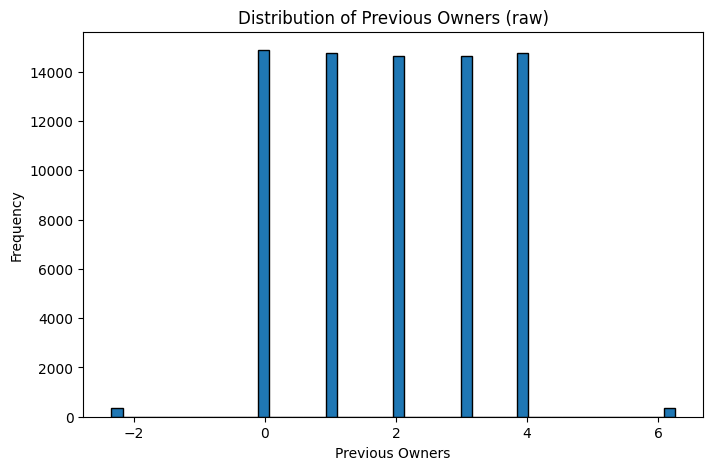

array([ 4.        ,  1.        , -2.34030622,  3.        ,  0.        ,
        2.        ,         nan, -2.34565   ,  6.25837066, -2.33512284,
        6.22789796,  6.25823052,  6.23017958, -2.33936045,  6.21772443,
        6.24583495, -2.29943868, -2.34010209, -2.31225953,  6.2482512 ,
       -2.31733109,  6.23308217,  6.24177863, -2.33744529])

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,previousOwners,hasDamage
carID,,,,,,,,,,,,
29021,Ford,FIESTA,2,12500,MANUAL,9102.0,PETROL,145.0,65.7,1.0,-2.340306,0.0
71677,VW,TIGUAN,1,29999,SEMI-AUTO,669.0,DIESEL,145.0,39.8,2.0,-2.345650,0.0
16962,Ford,FOCUS,1,19950,AUTOMATIC,7142.0,DIESEL,NaN,NaN,2.0,-2.340306,0.0
5994,Audi,None,0,31990,SEMI-AUTO,4432.0,PETROL,150.0,40.4,1.5,-2.335123,0.0
5038,Audi,RS6,0,97500,SEMI-AUTO,3220.0,PETROL,150.0,22.1,4.0,-2.335123,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
67526,VW,PASSAT,0,20998,SEMI-AUTO,15.0,DIESEL,145.0,49.6,1.6,-2.345650,0.0
75599,VW,UP,5,6795,MANUAL,10800.0,PETROL,20.0,61.4,1.0,-2.345650,0.0
28295,Ford,SMAX,3,17950,MANUAL,28280.0,PETROL,145.0,43.5,1.5,-2.340306,0.0


,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,previousOwners,hasDamage
carID,,,,,,,,,,,,
35263,Mercedes,CCLASS,<NA>,11295,AUTOMATIC,45000.0,PETROL,NaN,46.3,1.6,NaN,0.0
18304,Ford,None,4,9632,MANUAL,18814.0,PETROL,20.0,62.8,1.0,NaN,0.0
49135,Skoda,SCALA,0,17000,MANUAL,731.0,PETROL,150.0,50.4,1.0,NaN,0.0
37446,Mercedes,CCLASS,1,27099,SEMI-AUTO,1059.0,PETROL,145.0,45.6,1.5,NaN,0.0
1768,Audi,Q3,0,35990,SEMI-AUTO,6000.0,DIESEL,145.0,47.1,2.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
301,Audi,A7,6,19499,AUTOMATIC,47317.0,DIESEL,145.0,54.3,3.0,NaN,0.0
6295,Audi,A3,2,17650,MANUAL,6350.0,PETROL,150.0,55.4,1.5,NaN,0.0
21918,Ford,FIESTA,1,13998,MANUAL,10576.0,PETROL,145.0,58.9,1.0,NaN,0.0


<IntegerArray>
[4, 1, <NA>, 3, 0, 2, 6]
Length: 7, dtype: Int64

In [175]:
# =========================================
# previousOwners feature — Exploration and preprocessing
# =========================================

from IPython.display import display, HTML
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ---- Distribution of previousOwners (raw)
plt.figure(figsize=(8, 5))
plt.hist(df["previousOwners"].dropna(), bins=50, edgecolor="black")
plt.title("Distribution of Previous Owners (raw)")
plt.xlabel("Previous Owners")
plt.ylabel("Frequency")
plt.show()


# ---- Unique values
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>previousOwners — unique values</b>
</div>
"""))
display(df["previousOwners"].unique())


# ---- Invalid negative values
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>previousOwners — invalid negative values</b>
</div>
"""))
display(df[df["previousOwners"] < 0])


# ---- Missing values
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>previousOwners — missing values</b>
</div>
"""))
display(df[df["previousOwners"].isna()])


# ---- Helper: round owners to integer values
def round_owners_int(df):
    df = df.copy()
    df["previousOwners"] = pd.to_numeric(df["previousOwners"], errors="coerce")
    df["previousOwners"] = df["previousOwners"].round().astype("Int64")
    return df


# ---- Apply corrections
df = impossible_to_nan(df, "previousOwners")
df = round_owners_int(df)


# ---- Values after preprocessing
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>previousOwners — after preprocessing</b>
</div>
"""))
display(df["previousOwners"].unique())


# ---- Conclusion
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>Conclusion</b><br>
Negative values were identified as invalid and converted to <b>NaN</b>.
The <b>previousOwners</b> feature was rounded to integer values, ensuring
a consistent and interpretable representation suitable for modeling.
</div>
"""))


## **2.14 Hasdamage feature**

In [176]:
# =========================================
# hasDamage feature — Removal
# =========================================

from IPython.display import display, HTML

# ---- Unique values
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>hasDamage — unique values</b>
</div>
"""))
display(df["hasDamage"].unique())


# ---- Helper: remove hasDamage feature
def remove_hasdmg(df):
    df = df.copy()
    df = df.drop(columns=["hasDamage"], errors="ignore")
    return df


# ---- Apply removal
df = remove_hasdmg(df)


# ---- Verification
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>hasDamage — verification</b><br>
The feature has been successfully removed from the dataset.
</div>
"""))
display(df.head())


# ---- Conclusion
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>Conclusion</b><br>
The <b>hasDamage</b> feature contained a single constant value across all records,
providing no discriminatory power. It was therefore removed to avoid adding noise
and unnecessary dimensionality to the model.
</div>
"""))


array([ 0., nan])

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,previousOwners
carID,,,,,,,,,,,
69512,VW,GOLF,4,22290,SEMI-AUTO,28421.0,PETROL,NaN,11.417268,2.0,4
53000,Toyota,YARIS,1,13790,MANUAL,4589.0,PETROL,145.0,47.900000,1.5,1
6366,Audi,Q2,1,24990,SEMI-AUTO,3624.0,PETROL,145.0,40.900000,1.5,4
29021,Ford,FIESTA,2,12500,MANUAL,9102.0,PETROL,145.0,65.700000,1.0,<NA>
10062,BMW,2SERIES,1,22995,MANUAL,1000.0,PETROL,145.0,42.800000,1.5,3


## **2.15 Price exploration and separation**

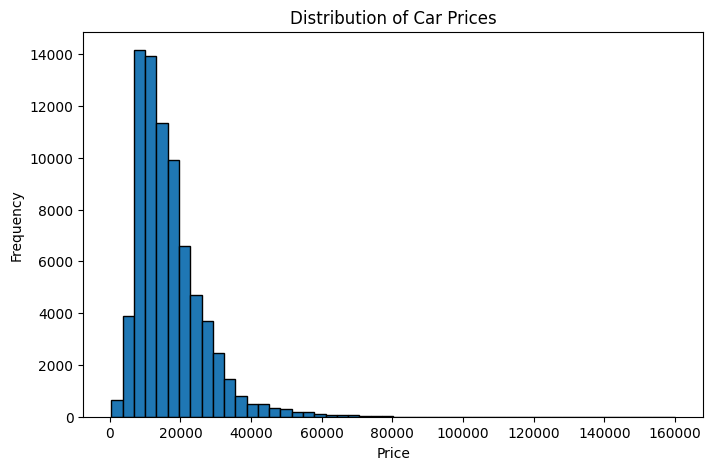

,price
count,75973.000000
mean,16881.889553
std,9736.926322
min,450.000000
25%,10200.000000
50%,14699.000000
75%,20950.000000
max,159999.000000


,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,previousOwners
carID,,,,,,,,,,
69512,VW,GOLF,4,SEMI-AUTO,28421.0,PETROL,NaN,11.417268,2.0,4
53000,Toyota,YARIS,1,MANUAL,4589.0,PETROL,145.0,47.900000,1.5,1
6366,Audi,Q2,1,SEMI-AUTO,3624.0,PETROL,145.0,40.900000,1.5,4
29021,Ford,FIESTA,2,MANUAL,9102.0,PETROL,145.0,65.700000,1.0,<NA>
10062,BMW,2SERIES,1,MANUAL,1000.0,PETROL,145.0,42.800000,1.5,3


,price
carID,
69512,22290
53000,13790
6366,24990
29021,12500
10062,22995


In [177]:
# =========================================
# Price (target) — Exploration and separation
# =========================================

from IPython.display import display, HTML
import matplotlib.pyplot as plt

# ---- Distribution of price
plt.figure(figsize=(8, 5))
plt.hist(df["price"].dropna(), bins=50, edgecolor="black")
plt.title("Distribution of Car Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()


# ---- Descriptive statistics
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>Price — descriptive statistics</b>
</div>
"""))
display(df["price"].describe())


# ---- Helper: separate features and target
def separar_y(df):
    df = df.copy()
    X = df.drop("price", axis=1)
    y = df["price"]
    return X, y


# ---- Apply separation
X, y = separar_y(df)


# ---- Verification
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>Feature / target separation</b><br>
<b>X</b> contains all explanatory features.<br>
<b>y</b> contains the target variable (<b>price</b>).
</div>
"""))

display(X.head())
display(y.head())


# ---- Conclusion
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>Conclusion</b><br>
The <b>price</b> variable was explored and validated as the regression target.
The dataset was successfully split into features (<b>X</b>) and target (<b>y</b>),
preparing the data for train/test splitting and pipeline-based modeling.
</div>
"""))


# **3. Missing Values Analysis & Handling**


In [178]:
# =========================================
# Missing values — Analysis and handling
# =========================================

from IPython.display import display, HTML
import pandas as pd

# ---- Missing values summary
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>Missing values — overview</b><br>
Number and percentage of missing values per feature.
</div>
"""))

missing = df.isnull().sum().sort_values(ascending=False)

missing_df = pd.DataFrame({
    "Missing Count": missing,
    "Missing Percentage": (missing / len(df)) * 100
})

display(missing_df)


# ---- Helper: fill categorical missing values with UNKNOWN
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>Categorical missing values — handling strategy</b><br>
Missing values in categorical features are explicitly filled with
<b>UNKNOWN</b> to preserve information and avoid data leakage.
</div>
"""))

def fill_cats_UNKNOWN(df, cats):
    df = df.copy()
    for column in cats:
        df[column] = df[column].fillna("UNKNOWN")
    return df


# ---- Conclusion
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>Conclusion</b><br>
Missing values were systematically analysed across all features.
Categorical missing values are handled explicitly using the <b>UNKNOWN</b>
category, while numerical missing values are intentionally left for
imputation within the machine learning pipeline.
</div>
"""))


,Missing Count,Missing Percentage
tax,8282,10.901241
mpg,7962,10.480039
engineSize,2034,2.677267
previousOwners,1921,2.528530
year,1849,2.433759
mileage,1832,2.411383
model,1578,2.077054
transmission,1522,2.003343
Brand,1521,2.002027
fuelType,1511,1.988864


# **4. Feature Engineering**


,mileage_per_year,power_efficiency
carID,,
69512,7105.25,0.175173
53000,4589.0,0.031315
6366,3624.0,0.036675
29021,4551.0,0.015221
10062,1000.0,0.035047


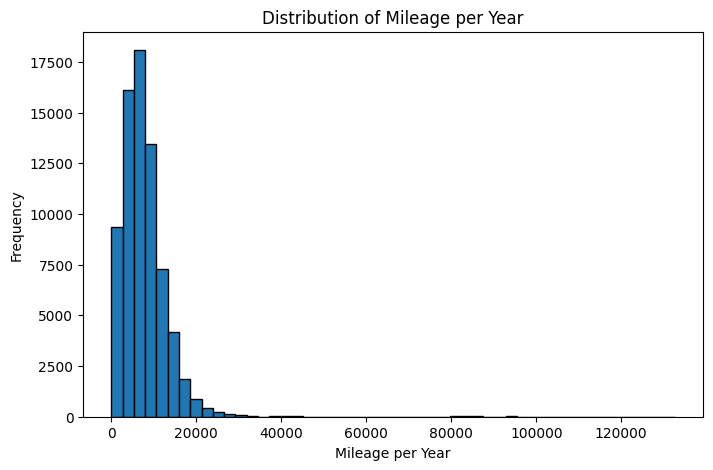

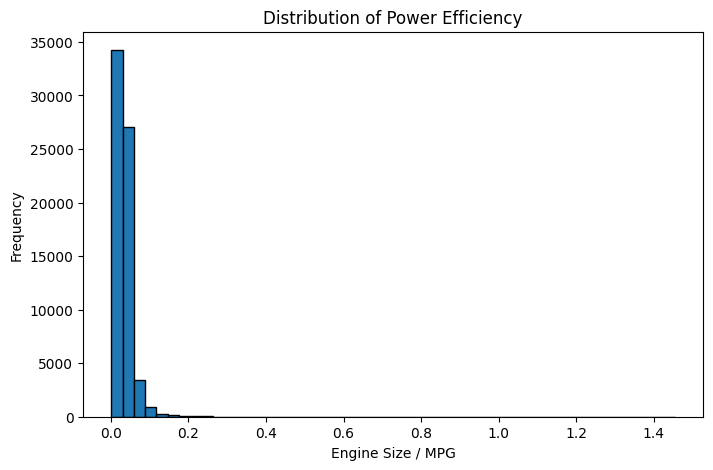

In [183]:
# =========================================
# Feature engineering — mileage_per_year & power_efficiency (ONE BLOCK)
# =========================================

from IPython.display import display, HTML
import matplotlib.pyplot as plt
import numpy as np

# ---- Section introduction
display(HTML("""
<div style="background-color:#e8f1ff; padding:12px; border-radius:8px; border-left:6px solid #1f77ff;">
<b>Feature engineering</b><br><br>
We create two additional numerical features to capture (1) vehicle usage intensity and
(2) the relationship between engine size and fuel efficiency.<br><br>
These features can help the model generalize better by providing normalized signals.
</div>
"""))

# ---- Feature: mileage per year
def mileage_per_year(df):
    df = df.copy()
    age_divisor = np.maximum(df["year"], 1)  # avoids division by zero when age == 0
    df["mileage_per_year"] = df["mileage"] / age_divisor
    return df

# ---- Feature: power efficiency
def power_efficiency(df):
    df = df.copy()
    df["power_efficiency"] = df["engineSize"] / df["mpg"]

    # Handle division-by-zero (inf) safely by capping at max finite value
    max_finite = df.loc[np.isfinite(df["power_efficiency"]), "power_efficiency"].max()
    df["power_efficiency"] = df["power_efficiency"].replace([np.inf], max_finite)

    return df

# ---- Apply feature engineering (SEQUENTIAL)
df = mileage_per_year(df)
df = power_efficiency(df)

# ---- Quick preview of engineered features
display(HTML("""
<div style="background-color:#e8f1ff; padding:12px; border-radius:8px; border-left:6px solid #1f77ff;">
<b>Preview</b><br>
Below we inspect the first rows of the newly engineered features.
</div>
"""))
display(df[["mileage_per_year", "power_efficiency"]].head())

# ---- Distribution: mileage_per_year
plt.figure(figsize=(8, 5))
plt.hist(df["mileage_per_year"].dropna(), bins=50, edgecolor="black")
plt.title("Distribution of Mileage per Year")
plt.xlabel("Mileage per Year")
plt.ylabel("Frequency")
plt.show()

# ---- Distribution: power_efficiency
plt.figure(figsize=(8, 5))
plt.hist(df["power_efficiency"].dropna(), bins=50, edgecolor="black")
plt.title("Distribution of Power Efficiency")
plt.xlabel("Engine Size / MPG")
plt.ylabel("Frequency")
plt.show()

# ---- Column groups for modeling
num_cols = [
    "year", "mileage", "tax", "mpg", "engineSize",
    "previousOwners", "mileage_per_year", "power_efficiency"
]
cat_cols = ["Brand", "model", "transmission", "fuelType"]
int_cols = ["year", "previousOwners"]
float_cols = ["mileage", "tax", "mpg", "engineSize", "mileage_per_year", "power_efficiency"]

# ---- Conclusion
display(HTML("""
<div style="background-color:#e8f1ff; padding:12px; border-radius:8px; border-left:6px solid #1f77ff;">
<b>Conclusion</b><br><br>
The engineered features <b>mileage_per_year</b> and <b>power_efficiency</b> add normalized
signals for vehicle usage and efficiency. We retain both features for modeling, while any
missing values and scaling will be handled later inside the machine learning pipeline.
</div>
"""))


In [186]:
df=fill_cats_UNKNOWN(df, cat_cols)

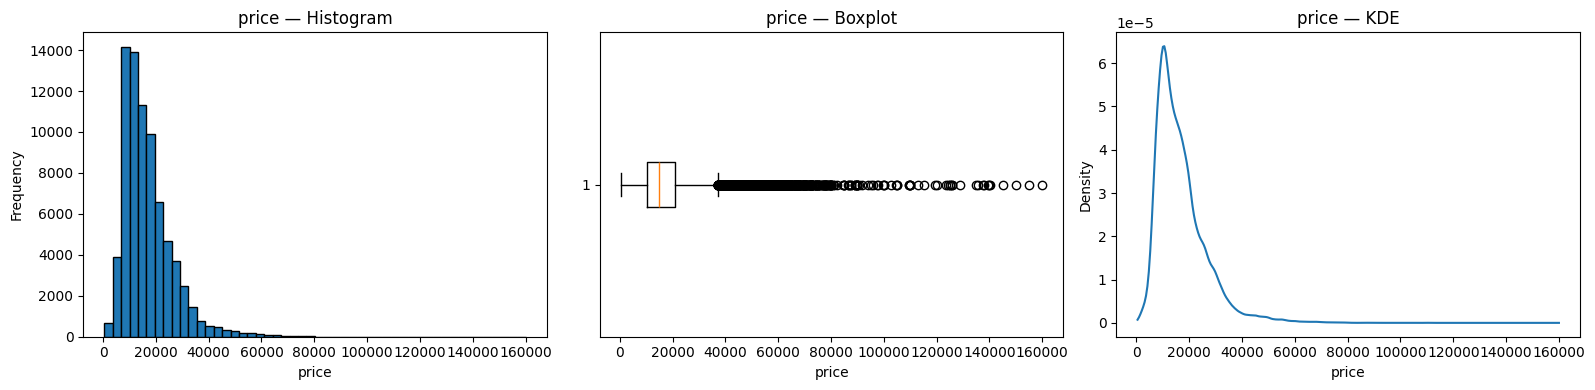

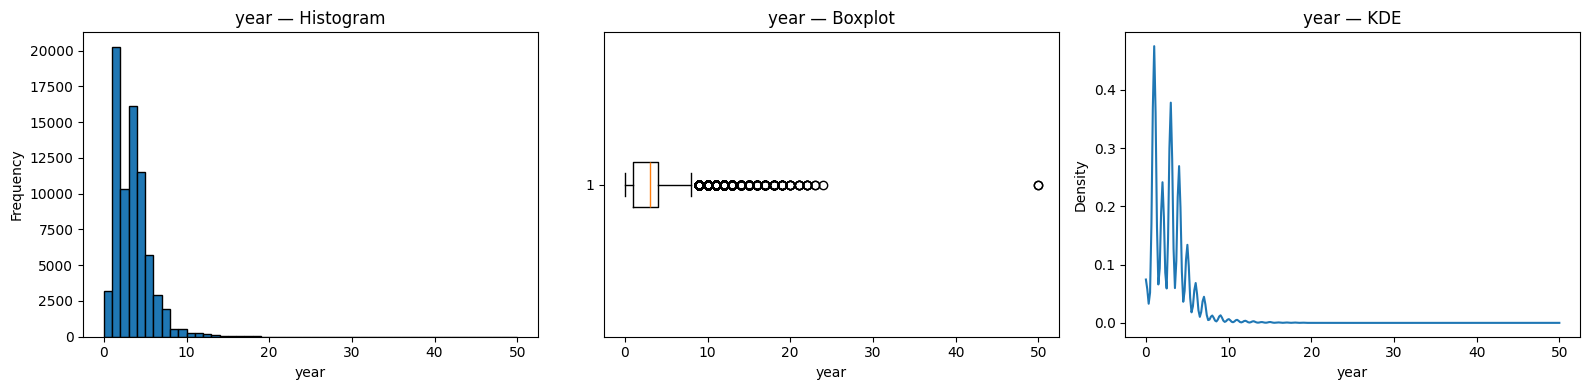

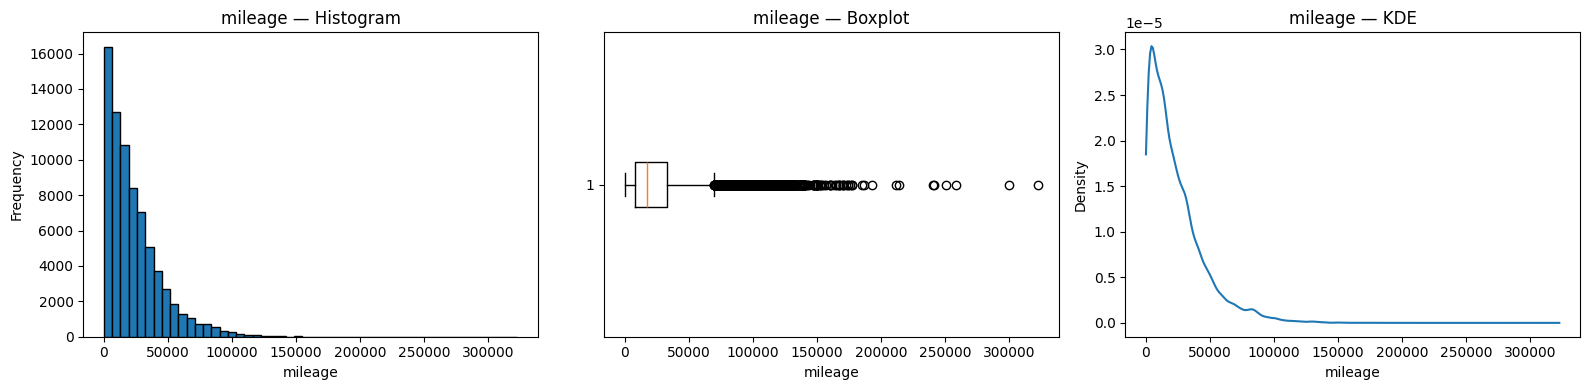

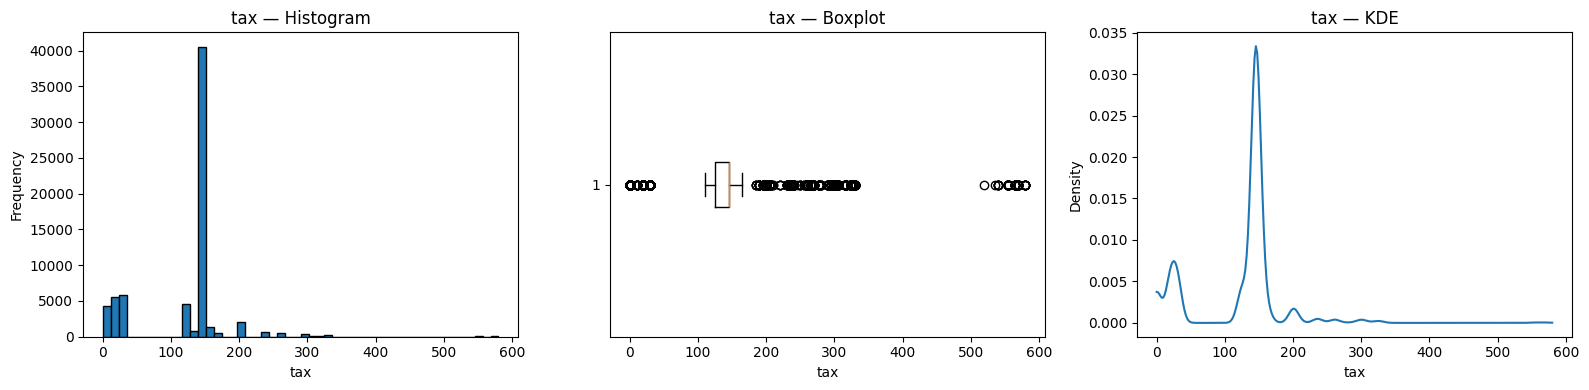

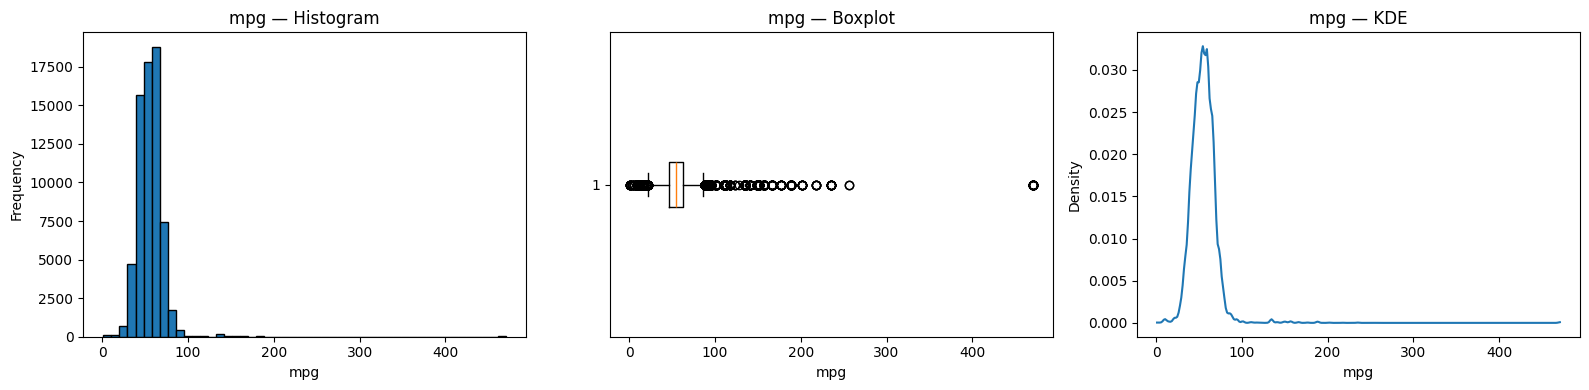

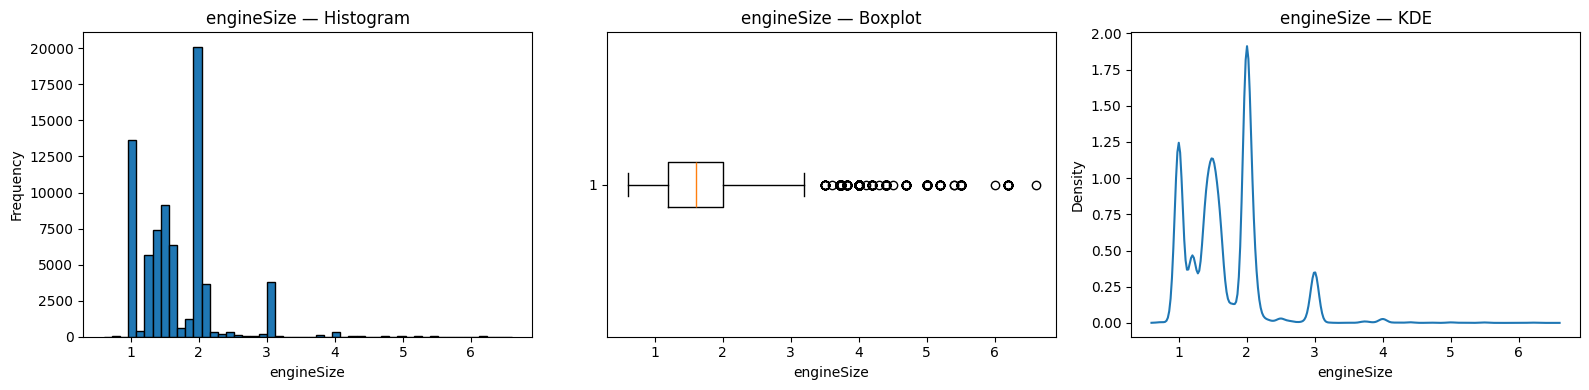

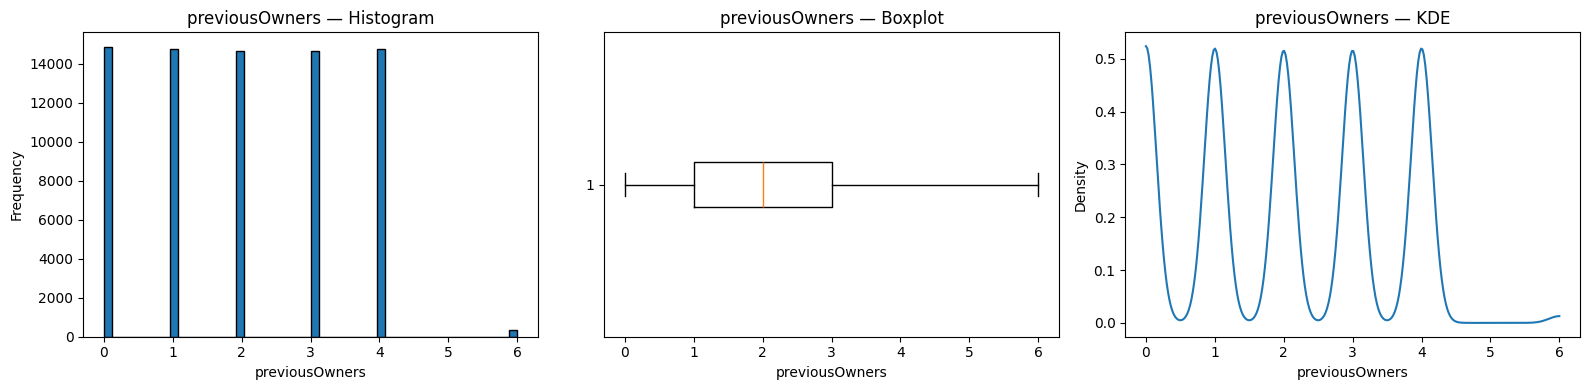

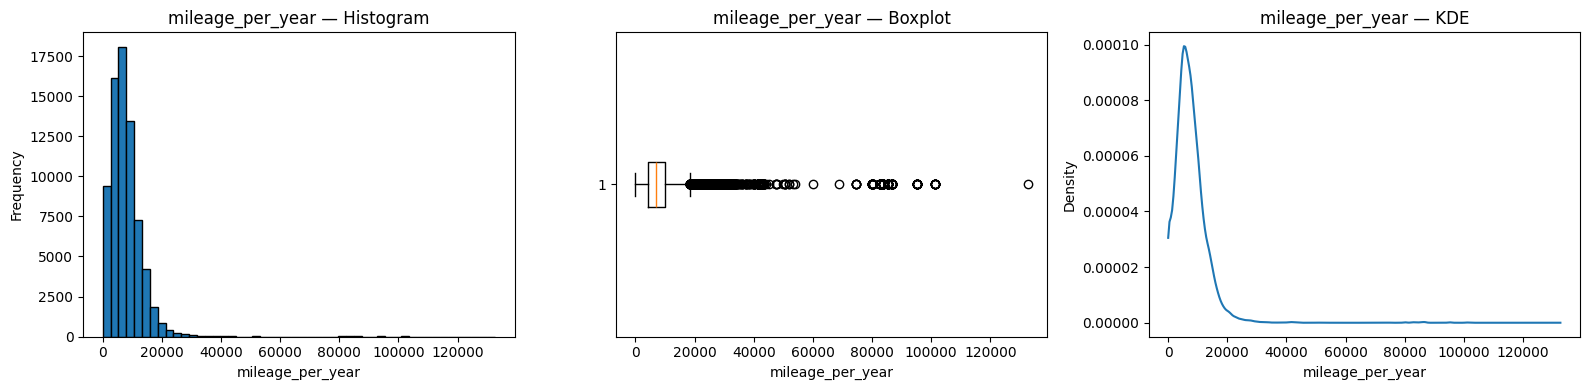

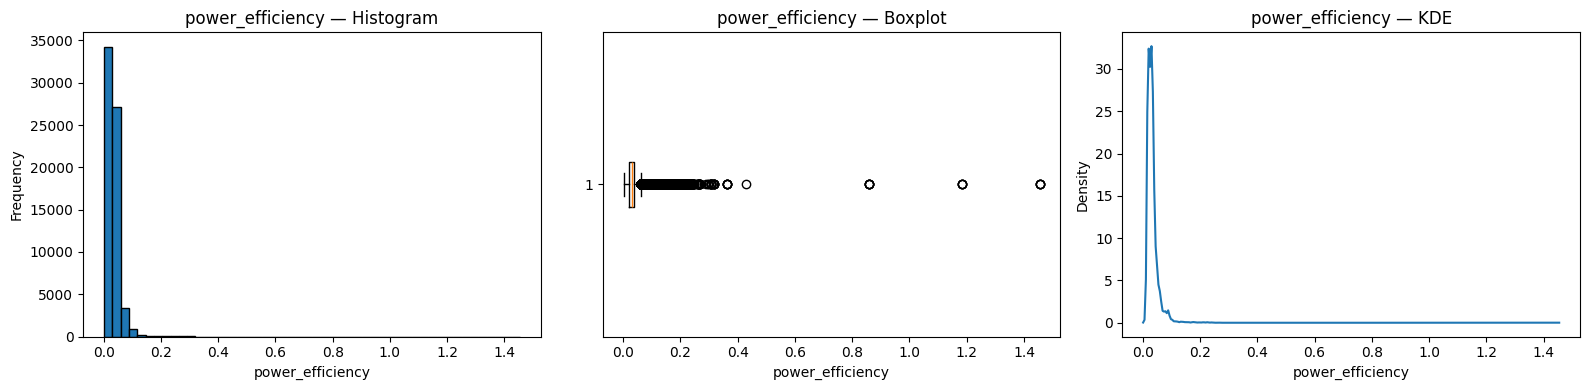

In [188]:
# =========================================
# Numerical Features — Histogram | Boxplot | KDE
# =========================================

from IPython.display import display, HTML
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# ---- Section introduction
display(HTML("""
<div style="background-color:#e8f1ff; padding:12px; border-radius:8px; border-left:6px solid #1f77ff;">
<b>Univariate analysis — numerical features</b><br><br>
Each row below shows, for a given numerical feature:
<ul>
<li>Histogram (distribution)</li>
<li>Boxplot (dispersion and outliers)</li>
<li>KDE plot (smoothed density)</li>
</ul>
</div>
"""))

# ---- Numerical columns from current pipeline
numeric_cols = [
    "price", "year", "mileage", "tax", "mpg",
    "engineSize", "previousOwners",
    "mileage_per_year", "power_efficiency"
]

numeric_cols = [c for c in numeric_cols if c in df.columns]

# ---- Plot per feature: 1 row × 3 plots
for col in numeric_cols:
    values = df[col].dropna()

    if len(values) < 5:
        continue

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    # ---- Histogram
    axes[0].hist(values, bins=50, edgecolor="black")
    axes[0].set_title(f"{col} — Histogram")
    axes[0].set_xlabel(col)
    axes[0].set_ylabel("Frequency")

    # ---- Boxplot
    axes[1].boxplot(values, vert=False)
    axes[1].set_title(f"{col} — Boxplot")
    axes[1].set_xlabel(col)

    # ---- KDE
    kde = gaussian_kde(values)
    x_vals = np.linspace(values.min(), values.max(), 300)
    axes[2].plot(x_vals, kde(x_vals))
    axes[2].set_title(f"{col} — KDE")
    axes[2].set_xlabel(col)
    axes[2].set_ylabel("Density")

    plt.tight_layout()
    plt.show()

# ---- Conclusion
display(HTML("""
<div style="background-color:#e8f1ff; padding:12px; border-radius:8px; border-left:6px solid #1f77ff;">
<b>Conclusion</b><br><br>
This layout enables direct visual comparison of distribution shape, dispersion,
and density for each numerical feature.<br><br>

The analysis confirms skewness and outliers in several variables, justifying the
use of robust scaling and pipeline-based preprocessing rather than manual clipping.
</div>
"""))




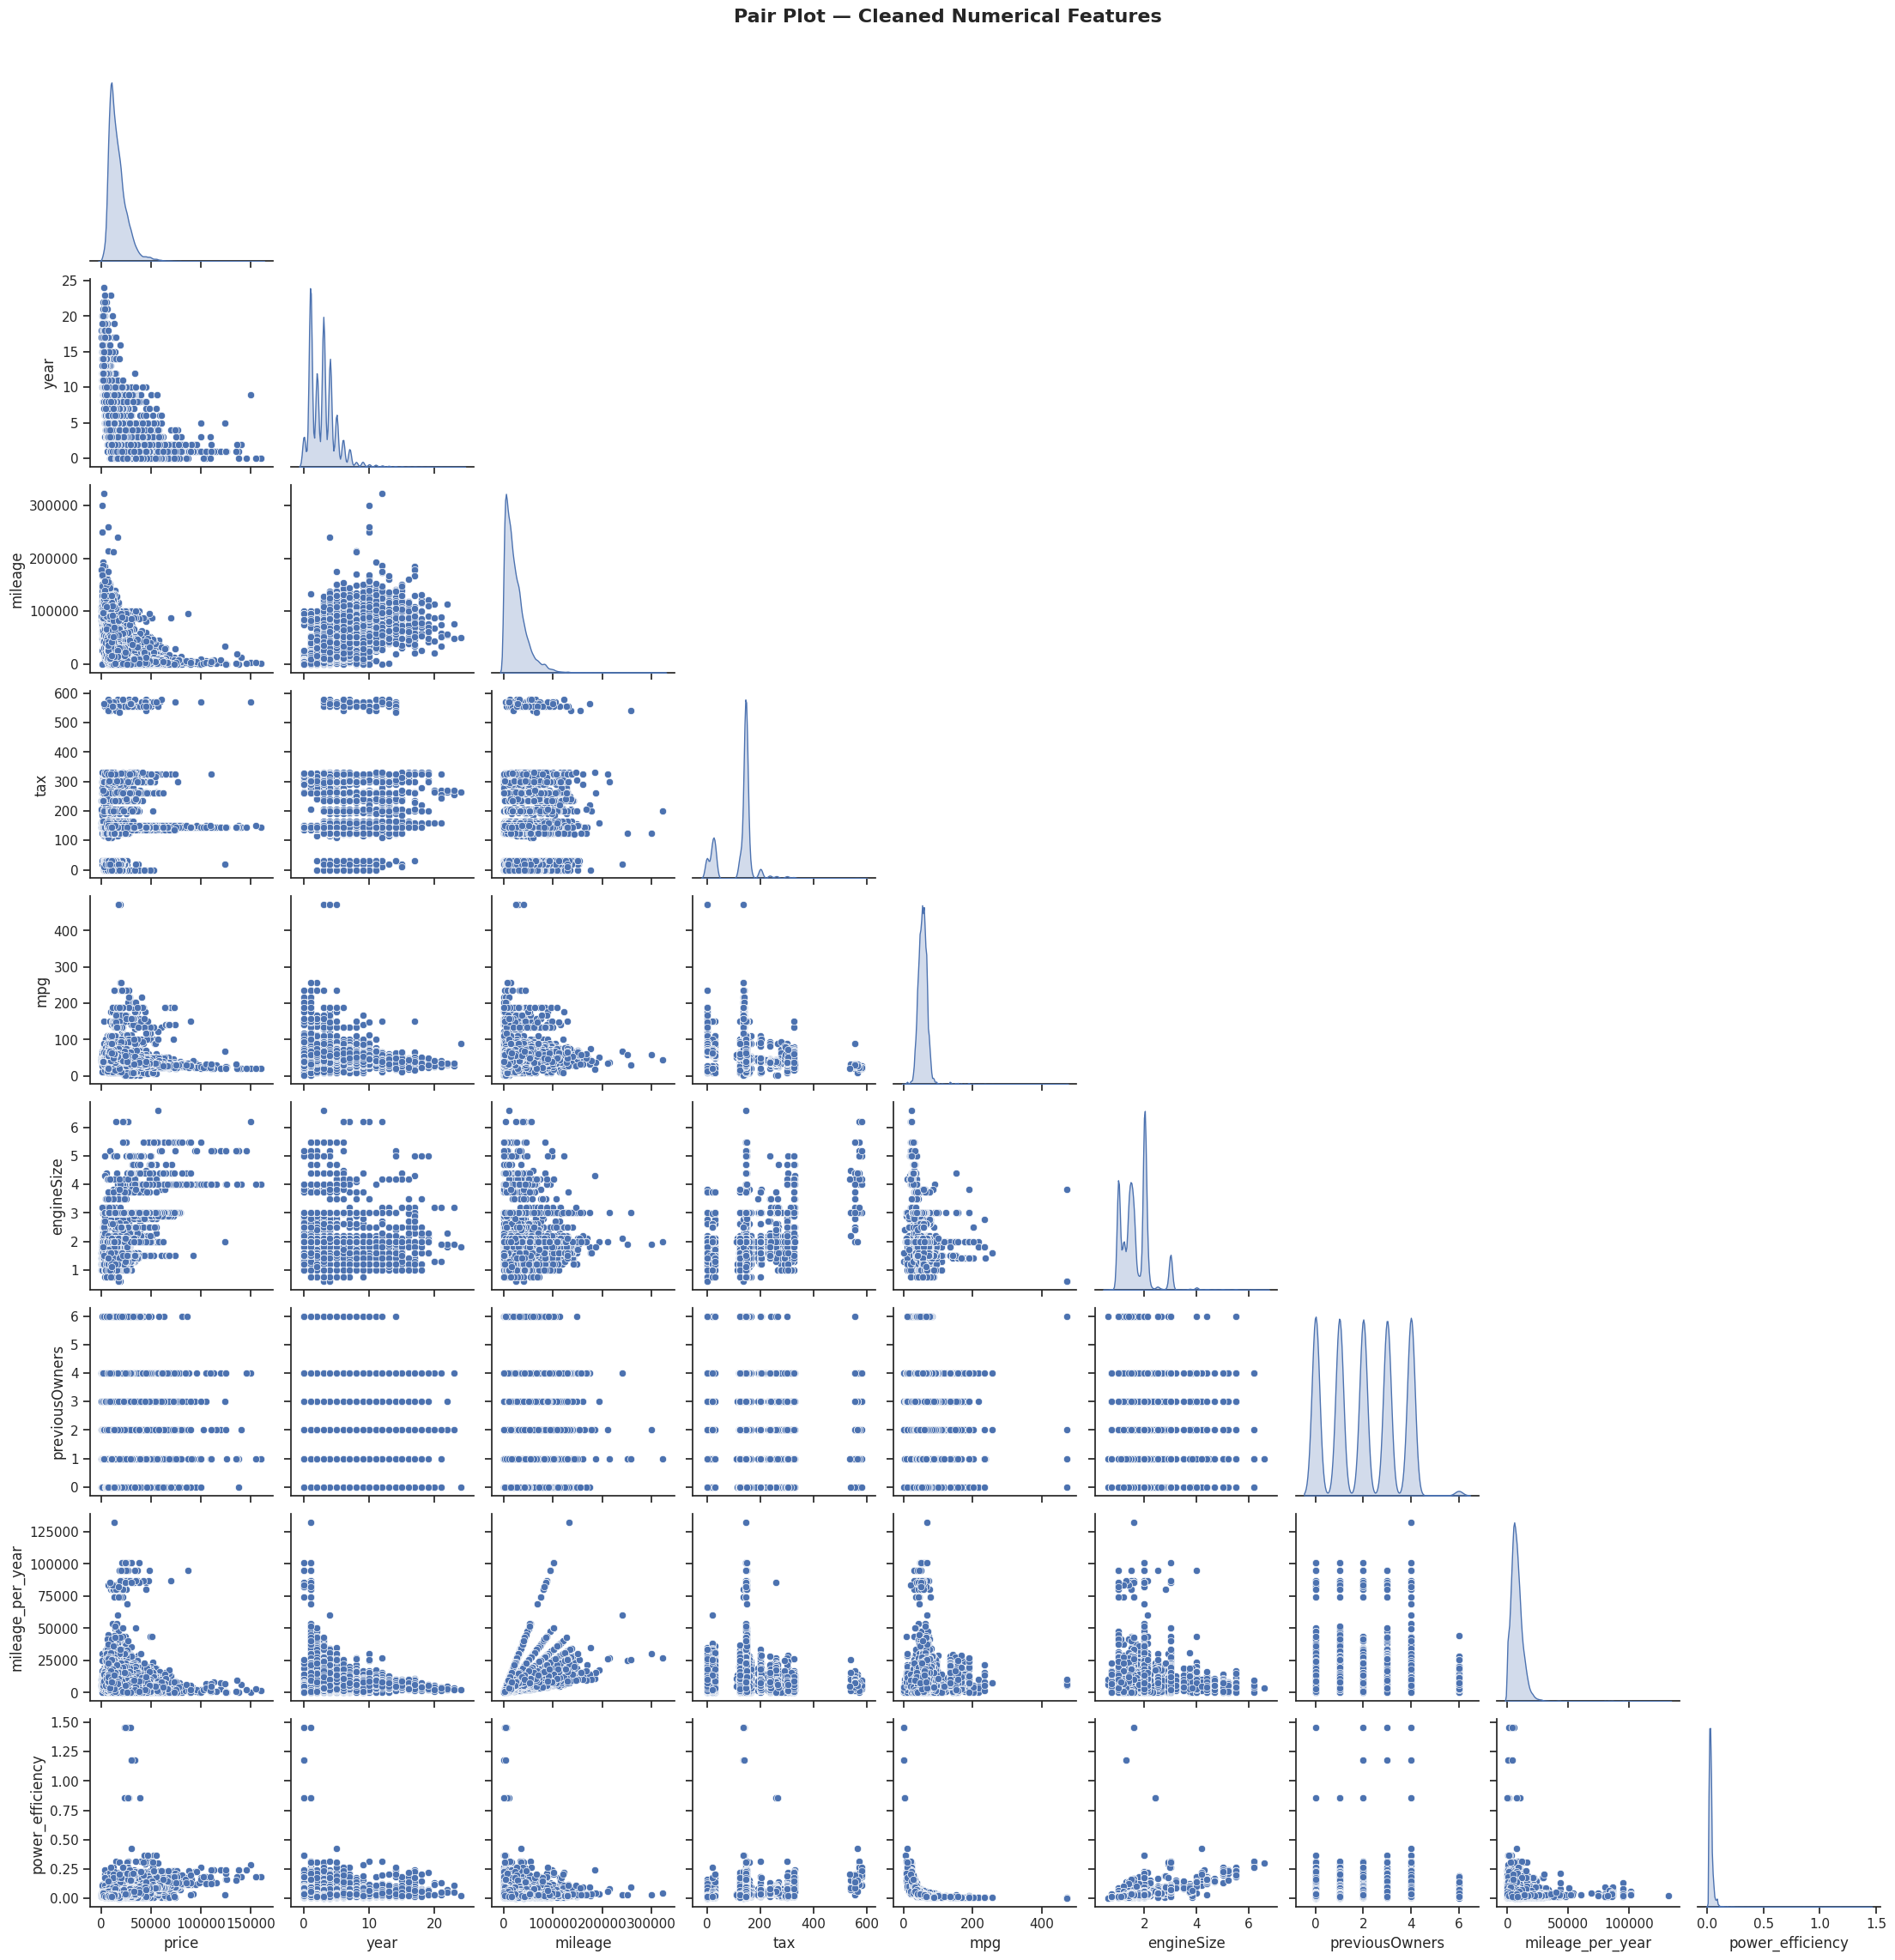

In [189]:
# =========================================
# Numerical features — Pair plot exploration
# =========================================

from IPython.display import display, HTML
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# ---- Section introduction
display(HTML("""
<div style="background-color:#e8f1ff; padding:12px; border-radius:8px; border-left:6px solid #1f77ff;">
<b>Pair plot — numerical feature relationships</b><br><br>
This visualization explores pairwise relationships between cleaned numerical
features, helping identify linear trends, non-linear patterns, and potential
collinearity before modeling.
</div>
"""))

# ---- Numerical features consistent with pipeline
numeric_cols = [
    "price", "year", "mileage", "tax", "mpg",
    "engineSize", "previousOwners",
    "mileage_per_year", "power_efficiency"
]

numeric_cols = [c for c in numeric_cols if c in df.columns]

display(HTML(f"""
<b>Numerical features included ({len(numeric_cols)}):</b><br>
{", ".join(numeric_cols)}
"""))

# ---- Drop rows with missing numerical values (required for pairplot)
pairplot_df = df[numeric_cols].dropna()

# ---- Aesthetics
sns.set(style="ticks", context="notebook")

# ---- Pair plot
pair_plot = sns.pairplot(
    pairplot_df,
    diag_kind="kde",
    corner=True
)

pair_plot.fig.suptitle(
    "Pair Plot — Cleaned Numerical Features",
    fontsize=16,
    fontweight="bold",
    y=1.02
)

plt.show()

# ---- Conclusion
display(HTML("""
<div style="background-color:#e8f1ff; padding:12px; border-radius:8px; border-left:6px solid #1f77ff;">
<b>Conclusion</b><br><br>
The pair plot highlights relationships between numerical variables, revealing
expected correlations (e.g. mileage vs mileage_per_year) and potential
redundancies.<br><br>

These insights inform feature selection and motivate the use of regularization
and scaling within the modeling pipeline.
</div>
"""))


# **5. Final cleaning Pipeline**

In [ ]:
# =========================================
# Final preprocessing pipeline — Consolidation
# =========================================

from IPython.display import display, HTML
import pandas as pd

# ---- Section introduction
display(HTML("""
<div style="background-color:#e8f1ff; padding:12px; border-radius:8px; border-left:6px solid #1f77ff;">
<b>Final preprocessing pipeline</b><br><br>
All previously defined data cleaning and feature engineering steps are now
consolidated into a single reusable function.<br><br>

This ensures a consistent, ordered, and reproducible preprocessing workflow
that can be safely reused for training, validation, and inference.
</div>
"""))

# ---- Unified preprocessing function
def clean_df(df, valid_models, cat_cols):
    df = df.copy()
    df = carID_como_index(df)
    df = fuzzy_marcas(df)
    df = fuzzy_modelos(df, valid_models)
    df = limpar_anos(df)
    df = fuzzy_transmissao(df)
    df = impossible_to_nan(df, "mileage")
    df = mileage_per_year(df)
    df = fuzzy_fuel(df)
    df = impossible_to_nan(df, "tax")
    df = impossible_to_nan(df, "mpg")
    df = impossible_to_nan(df, "engineSize", 0.6)
    df = power_efficiency(df)
    df = drop_paint(df)
    df = impossible_to_nan(df, "previousOwners")
    df = round_owners_int(df)
    df = remove_hasdmg(df)
    df = fill_cats_UNKNOWN(df, cat_cols)
    return df


# ---- Apply final preprocessing pipeline
og_df = clean_df(og_df, valid_models, cat_cols)

# ---- Validation check
assert pd.testing.assert_frame_equal(df, og_df) is None


# ---- Section conclusion
display(HTML("""
<div style="background-color:#e8f1ff; padding:12px; border-radius:8px; border-left:6px solid #1f77ff;">
<b>Conclusion</b><br><br>
The assertion confirms that the consolidated preprocessing pipeline produces
exactly the same dataset as the step-by-step preprocessing performed earlier.<br><br>

This validates the correctness of the pipeline and guarantees a consistent,
leakage-free data preparation stage for all subsequent modeling steps.
</div>
"""))


acess that all function were applied the same way as in clean_df.

# Feature Selection

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(X,y, test_size = 0.3, random_state = RANDOM_SEED, shuffle = True)

In [ ]:
df.dtypes

Brand                object
model                object
year                  Int64
price                 int64
transmission         object
mileage             float64
fuelType             object
tax                 float64
mpg                 float64
engineSize          float64
paintQuality%       float64
previousOwners        Int64
mileage_per_year    Float64
power_efficiency    float64
dtype: object

In [ ]:
def fill_nans(X, ints, floats, fill_values=None):
    X = X.copy()

    if fill_values is None:
        fill_values = {"float": {}, "int": {}}
        for column in floats:
            mean_to_fill = X[column].mean()
            X[column] = X[column].fillna(mean_to_fill)
            fill_values["float"][column] = mean_to_fill

        for column in ints:
            median_to_fill = X[column].median()
            X[column] = X[column].fillna(median_to_fill).astype("Int64")
            fill_values["int"][column] = median_to_fill

        return X, fill_values
    else:
        for col in floats:
            X[col] = X[col].fillna(fill_values["float"][col])
        for col in ints:
            X[col] = X[col].fillna(fill_values["int"][col]).astype("Int64")

        return X

In [ ]:
X_train, fill_values = fill_nans(X_train, int_cols, float_cols)
X_val = fill_nans(X_val, int_cols, float_cols, fill_values)

Most models we used can't handle numeric missing data in the training data, so we inpute missing values(the exeption is HGB).   
On float types we inpute with mean and median with int types.

In [ ]:
X_train.info()
X_train.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 53181 entries, 39423 to 35376
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Brand             53181 non-null  object 
 1   model             53181 non-null  object 
 2   year              53181 non-null  Int64  
 3   transmission      53181 non-null  object 
 4   mileage           53181 non-null  float64
 5   fuelType          53181 non-null  object 
 6   tax               53181 non-null  float64
 7   mpg               53181 non-null  float64
 8   engineSize        53181 non-null  float64
 9   paintQuality%     52139 non-null  float64
 10  previousOwners    53181 non-null  Int64  
 11  mileage_per_year  53181 non-null  Float64
 12  power_efficiency  53181 non-null  float64
dtypes: Float64(1), Int64(2), float64(6), object(4)
memory usage: 5.8+ MB


,year,mileage,tax,mpg,engineSize,paintQuality%,previousOwners,mileage_per_year,power_efficiency
count,53181.0,53181.000000,53181.000000,53181.000000,53181.000000,52139.000000,53181.0,53181.0,53181.000000
mean,2.925537,23322.431680,121.445982,55.181389,1.671665,64.482321,2.015099,7657.920557,0.033790
std,2.132121,21290.673805,60.842636,15.286735,0.553473,21.025020,1.423351,5772.678171,0.025188
min,0.0,1.000000,0.000000,1.100000,0.600000,1.638913,0.0,0.052632,0.001274
25%,1.0,7845.000000,121.445982,47.100000,1.300000,47.000000,1.0,4444.0,0.022414
50%,3.0,18033.000000,145.000000,55.181389,1.600000,64.000000,2.0,7092.25,0.031847
75%,4.0,32025.000000,145.000000,61.400000,2.000000,82.000000,3.0,9762.4,0.036101
max,50.0,323000.000000,580.000000,470.800000,6.200000,125.594308,6.0,132644.0,1.454545


In [ ]:
def plot_nums(X, num_cols):
    outlier_counts=[]
    for col in num_cols:
        fig, axes = plt.subplots(1, 2, figsize=(10, 4))
        fig.suptitle(col, fontsize=14, fontweight='bold')

        # Boxplot
        sns.boxplot(y=X[col], ax=axes[0], color='skyblue')
        axes[0].set_title("Boxplot")

        # Histogram
        sns.histplot(X[col], kde=True, ax=axes[1], color='salmon')
        axes[1].set_title("Histogram")
    plt.tight_layout()
    plt.show()
    for item in num_cols:
    #   find and count the outliers of metric features
        q1 = X[item].quantile(0.25)
        q3 = X[item].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        lower_outliers = (X[item] < lower).sum()
        upper_outliers = (X[item] > upper).sum()
        lower_pct = (lower_outliers / len(X)) * 100
        upper_pct = (upper_outliers / len(X)) * 100
        #create a dictionary with the feature,#outlier and percentage of outliers
        outlier_counts.append({
        "Feature": item,
        "Lower Outlier Count": lower_outliers,
        "Upper Outlier Count": upper_outliers,
        "Lower Outlier %": lower_pct,
        "Upper Outlier %": upper_pct
    })
    df_outlier = pd.DataFrame(outlier_counts)
    return df_outlier

We plot numeric features for outlier/skew inspection.

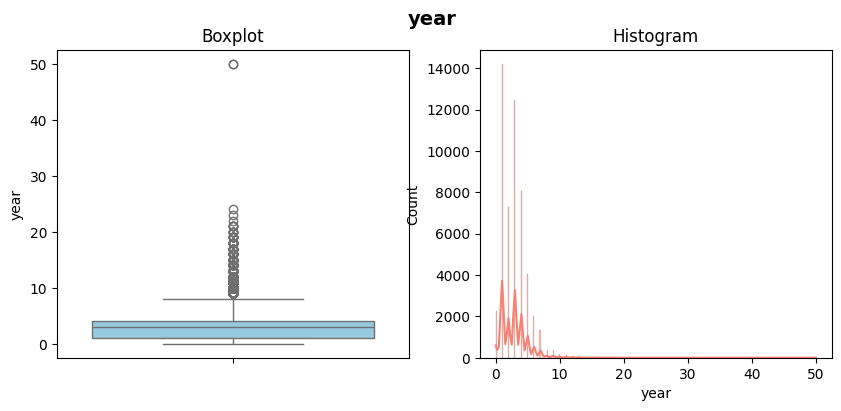

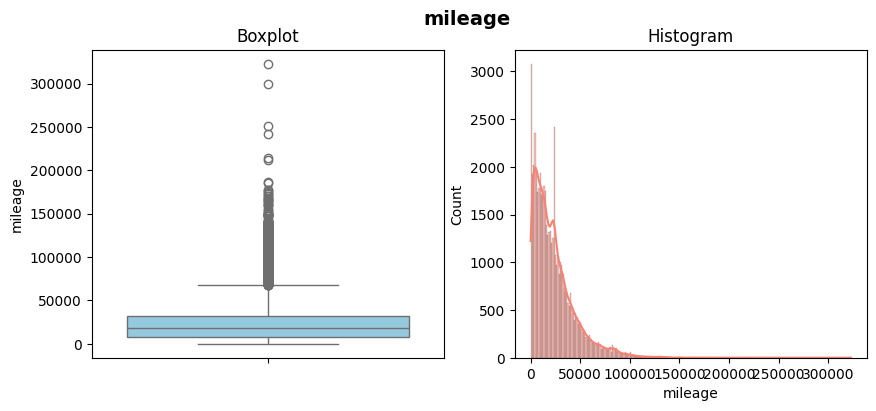

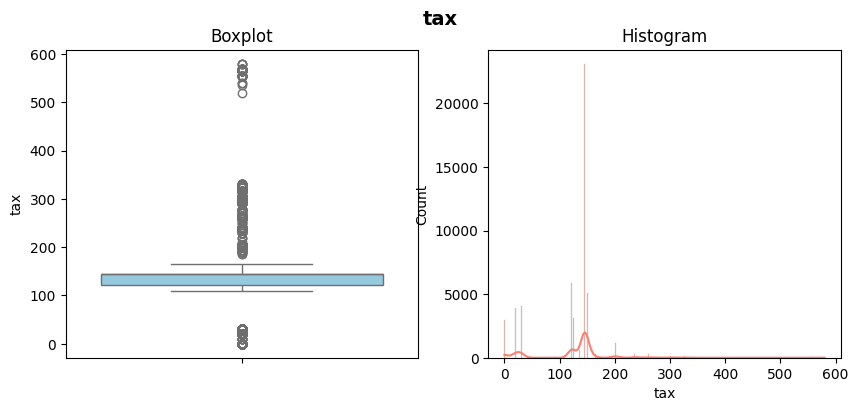

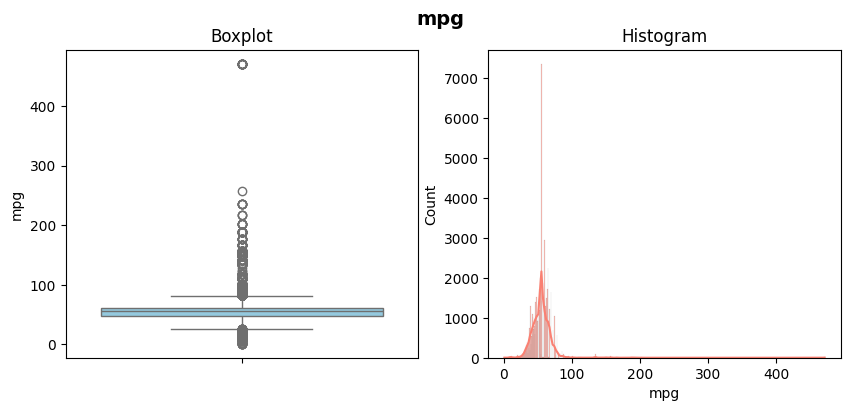

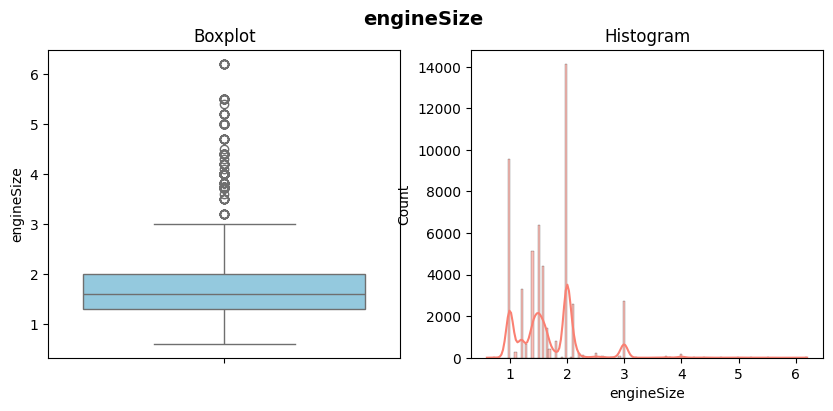

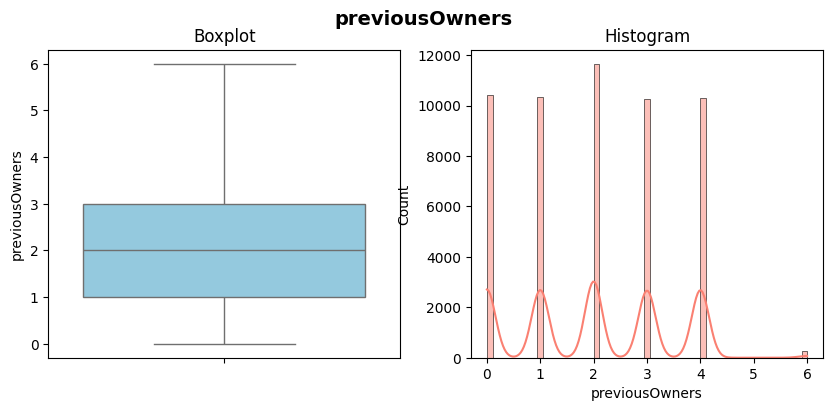

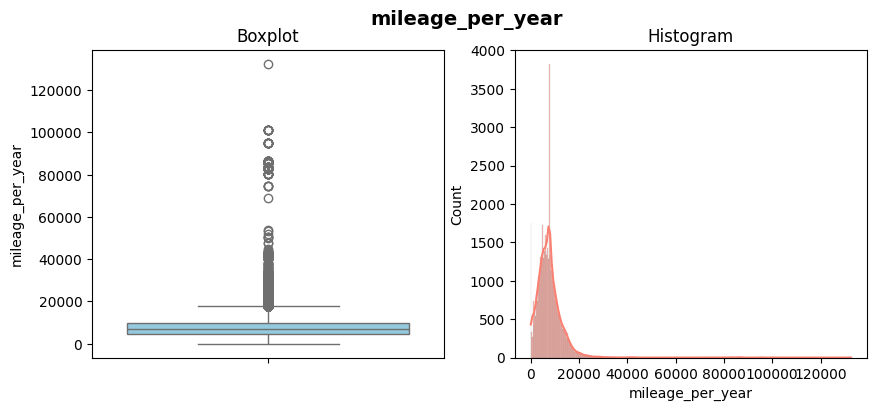

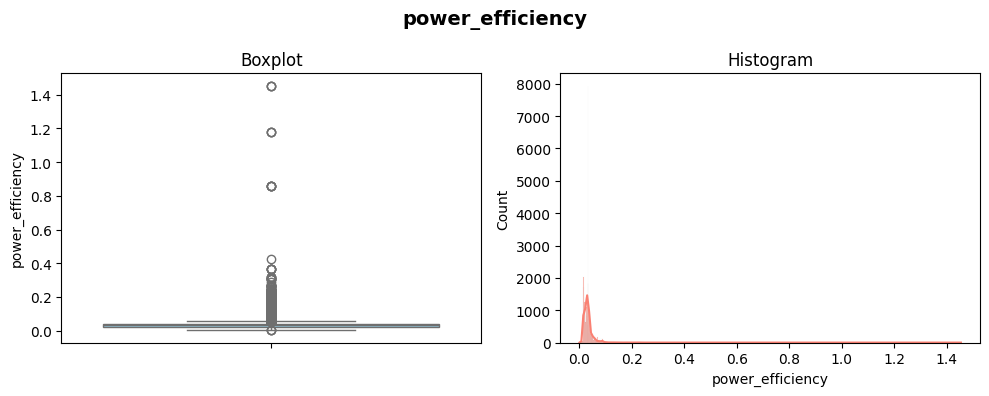

,Feature,Lower Outlier Count,Upper Outlier Count,Lower Outlier %,Upper Outlier %
0,year,0,1082,0.000000,2.034561
1,mileage,0,2424,0.000000,4.558019
2,tax,10941,2942,20.573137,5.532051
3,mpg,353,870,0.663771,1.635923
4,engineSize,0,458,0.000000,0.861210
5,previousOwners,0,0,0.000000,0.000000
6,mileage_per_year,0,1666,0.000000,3.132698
7,power_efficiency,3,3853,0.005641,7.245069


In [ ]:
plot_nums(X_train, num_cols)

All of our features are heavy right skewed , expect previousOwners ,tax and engine size.  
We didn't transformarm previousOwners because the features is already well behabed(low skew and no outliers).  
Year wasn't transformed, due to the fact year is temporal feature , so transforming would decrease it's usefullness.  
Milleage and milleage_per_year were transformed by using log1p due to the fact that they both have long tails and milleage_per_year is ratio , so log1 is usefull to compress ratio.  
EngineSize was transformed only with clipping(upper and lower) , due to the fact that there's only mild skew and engineSize is mostly discret, so a log transformation would destroy this binning.  
Mpg has a prety symetric shape, but a heavy left tail , so the best solution is just to clip the right tail.
Power_efficiency was transformed with clipping due to the fact, that a log transformation, would explode values into +infity this can be explained because power_efficiency is ration with alot of values around 0.  
Finally tax  was transformed with power transformation to preserve the specific spikes at specific tax brackets.

In [ ]:
X_train.describe()

,year,mileage,tax,mpg,engineSize,paintQuality%,previousOwners,mileage_per_year,power_efficiency
count,53181.0,53181.000000,53181.000000,53181.000000,53181.000000,52139.000000,53181.0,53181.0,53181.000000
mean,2.925537,23322.431680,121.445982,55.181389,1.671665,64.482321,2.015099,7657.920557,0.033790
std,2.132121,21290.673805,60.842636,15.286735,0.553473,21.025020,1.423351,5772.678171,0.025188
min,0.0,1.000000,0.000000,1.100000,0.600000,1.638913,0.0,0.052632,0.001274
25%,1.0,7845.000000,121.445982,47.100000,1.300000,47.000000,1.0,4444.0,0.022414
50%,3.0,18033.000000,145.000000,55.181389,1.600000,64.000000,2.0,7092.25,0.031847
75%,4.0,32025.000000,145.000000,61.400000,2.000000,82.000000,3.0,9762.4,0.036101
max,50.0,323000.000000,580.000000,470.800000,6.200000,125.594308,6.0,132644.0,1.454545


For nan or, in this case, after pre-processing UNKNOWN car brands it's possible to infer them if the brand for the same record is correct. The way we do this is by building a dictionary with the most common not UNKNOWN brand name for each model and then searching for missing brand names there. This, unfortunately, is not a deterministic process and requires statistical information about the data so in order not to cause data leakage we need to build the dictionary on training data and then apply it to the test/validation data.

In [ ]:
def infer_brand_fit(df_train):
    model_to_brand = (
        df_train[df_train["Brand"] != "UNKNOWN"]
        .groupby("model")["Brand"]
        .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else "UNKNOWN")
        .to_dict()
    )
    return model_to_brand


def infer_brand_apply(df, model_to_brand):
    df = df.copy()
    df["Brand"] = df.apply(
        lambda row: (
            row["Brand"]
            if row["Brand"] != "UNKNOWN"
            else model_to_brand.get(row["model"], "UNKNOWN")
        ),
        axis=1
    )
    return df

In [ ]:
X_train[X_train["Brand"] =="UNKNOWN"]

,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,mileage_per_year,power_efficiency
carID,,,,,,,,,,,,,
4297,UNKNOWN,A5,4,SEMI-AUTO,27385.0,PETROL,260.000000,35.800000,3.0,90.0,1,6846.25,0.083799
3538,UNKNOWN,Q5,3,MANUAL,55215.0,PETROL,235.000000,37.700000,2.0,95.0,4,7657.920557,0.053050
31896,UNKNOWN,SANTAFE,1,SEMI-AUTO,7119.0,DIESEL,145.000000,39.200000,2.2,39.0,0,7119.0,0.056122
35310,UNKNOWN,CCLASS,7,AUTOMATIC,68000.0,DIESEL,121.445982,55.181389,2.1,87.0,3,9714.285714,0.033790
40719,UNKNOWN,CCLASS,4,AUTOMATIC,30385.0,DIESEL,121.445982,55.181389,2.1,75.0,1,7596.25,0.033790
...,...,...,...,...,...,...,...,...,...,...,...,...,...
14626,UNKNOWN,1SERIES,7,AUTOMATIC,62000.0,DIESEL,30.000000,64.200000,2.0,65.0,3,8857.142857,0.031153
48145,UNKNOWN,KODIAQ,1,MANUAL,3053.0,DIESEL,145.000000,52.300000,2.0,32.0,0,3053.0,0.038241
37742,UNKNOWN,GLACLASS,6,SEMI-AUTO,52722.0,DIESEL,145.000000,55.400000,2.1,35.0,1,8787.0,0.037906


In [ ]:
model_to_brand = infer_brand_fit(X_train)
X_train = infer_brand_apply(X_train, model_to_brand)
X_val   = infer_brand_apply(X_val, model_to_brand)
X_train[X_train["Brand"] == "UNKNOWN"]

,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,mileage_per_year,power_efficiency
carID,,,,,,,,,,,,,
69305,UNKNOWN,TIGUA,4,SEMI-AUTO,23322.431680,DIESEL,160.000000,49.6,2.000000,86.000000,3,7657.920557,0.040323
35445,UNKNOWN,CCLAS,7,AUTOMATIC,68000.000000,DIESEL,145.000000,53.3,2.100000,94.000000,1,9714.285714,0.039400
38260,UNKNOWN,CLCLASS,3,SEMI-AUTO,23592.000000,DIESEL,20.000000,67.3,2.100000,91.000000,0,7864.0,0.031204
36973,UNKNOWN,GLACLASS,1,SEMI-AUTO,17471.000000,DIESEL,145.000000,67.3,2.100000,70.000000,2,17471.0,0.031204
5908,UNKNOWN,A,5,SEMI-AUTO,56875.000000,DIESEL,150.000000,53.3,2.000000,69.000000,0,11375.0,0.037523
39351,UNKNOWN,GLECLASS,5,AUTOMATIC,13212.000000,PETROL,570.000000,23.7,1.671665,80.000000,2,2642.4,0.033790
62403,UNKNOWN,ASTR,4,MANUAL,32891.000000,DIESEL,20.000000,72.4,1.600000,76.000000,3,8222.75,0.022099
37971,UNKNOWN,CLSCLASS,1,AUTOMATIC,30000.000000,DIESEL,150.000000,47.9,2.900000,74.000000,1,30000.0,0.060543
14098,UNKNOWN,X,6,AUTOMATIC,37905.000000,DIESEL,165.000000,52.3,2.000000,87.000000,0,6317.5,0.038241


In [ ]:
def outliers_skews_train(X):
    X = X.copy()
    outlier_info = {}

    if "mileage" in X.columns:
        X["mileage"] = np.log1p(X["mileage"])
        outlier_info["mileage"] = {"log1p_transform": True}

    if "tax" in X.columns:
        pt = PowerTransformer(method="yeo-johnson")
        X["tax"] = pt.fit_transform(X[["tax"]]).flatten()
        outlier_info["tax"] = pt

    if "mpg" in X.columns:
        upper = X["mpg"].quantile(0.975)
        X["mpg"] = X["mpg"].clip(upper=upper)
        outlier_info["mpg"] = {"upper": upper}

    if "engineSize" in X.columns:
        lower = X["engineSize"].quantile(0.01)
        upper = X["engineSize"].quantile(0.99)
        X["engineSize"] = X["engineSize"].clip(lower=lower, upper=upper)
        outlier_info["engineSize"] = {"lower": lower, "upper": upper}

    if "milleage_per_year" in X.columns:
        X["milleage_per_year"] = np.log1p(X["milleage_per_year"])
        outlier_info["milleage_per_year"] = {"log1p_transform": True}

    if "power_efficiency" in X.columns:
        upper = X["power_efficiency"].quantile(0.99)
        X["power_efficiency"] = X["power_efficiency"].clip(upper=upper)
        outlier_info["power_efficiency"] = {"upper": upper}
    return X, outlier_info

def outliers_skews_test(X, outlier_info):
    X = X.copy()


    if "mileage" in outlier_info and "mileage" in X.columns:
        if outlier_info["mileage"].get("log1p_transform", True):
            X["mileage"] = np.log1p(X["mileage"])

    if "tax" in outlier_info and "tax" in X.columns:
        pt = outlier_info["tax"]
        X["tax"] = pt.transform(X[["tax"]]).flatten()

    if "mpg" in outlier_info and "mpg" in X.columns:
        X["mpg"] = X["mpg"].clip(upper=outlier_info["mpg"]["upper"])

    if "engineSize" in outlier_info and "engineSize" in X.columns:
        X["engineSize"] = X["engineSize"].clip(
            lower=outlier_info["engineSize"]["lower"],
            upper=outlier_info["engineSize"]["upper"])

    if "milleage_per_year" in outlier_info and "milleage_per_year" in X.columns:
        if outlier_info["milleage_per_year"].get("log1p_transform", True):
            X["milleage_per_year"] = np.log1p(X["milleage_per_year"])

    if "power_efficiency" in outlier_info and "power_efficiency" in X.columns:
        X["power_efficiency"] = X["power_efficiency"].clip(upper=outlier_info["power_efficiency"]["upper"])

    return X

In [ ]:
X_train, outlier_info = outliers_skews_train(X_train)
X_val = outliers_skews_test(X_val, outlier_info)

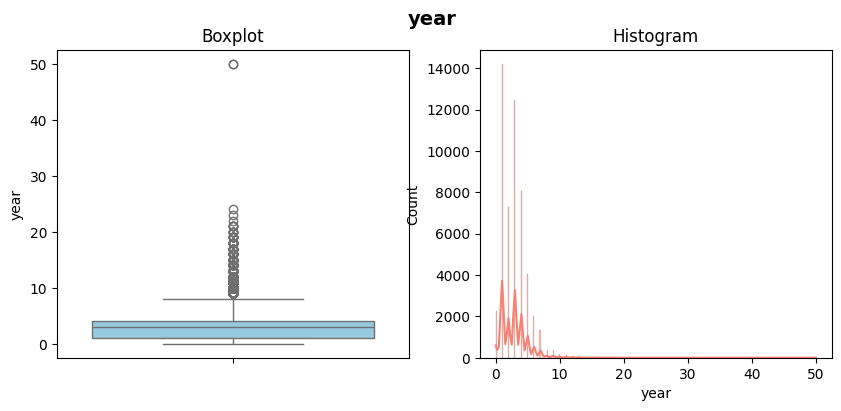

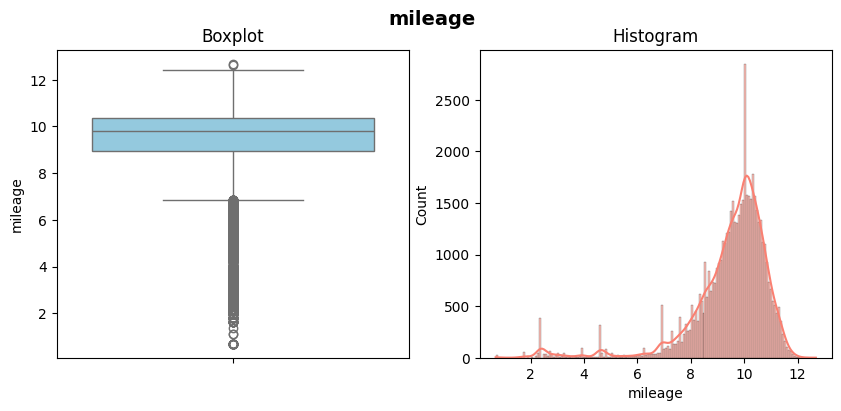

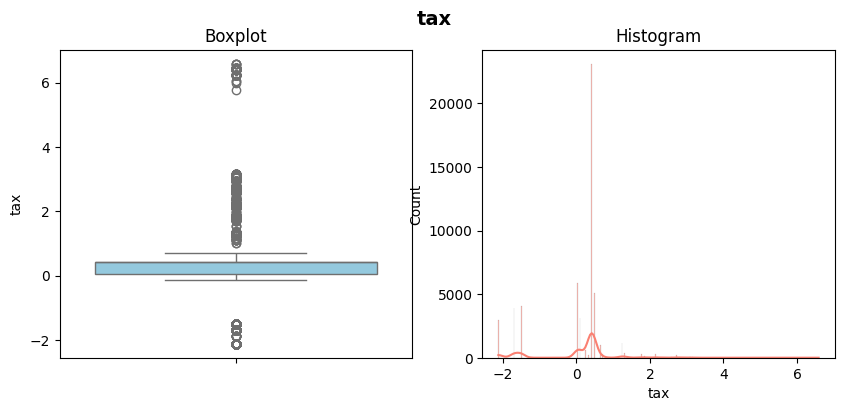

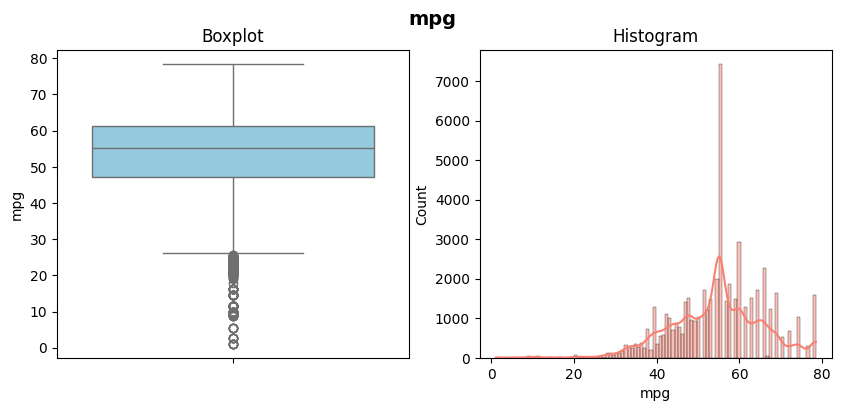

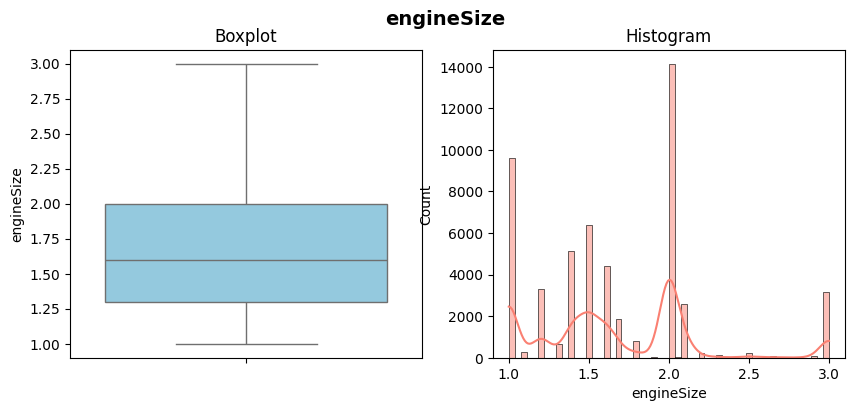

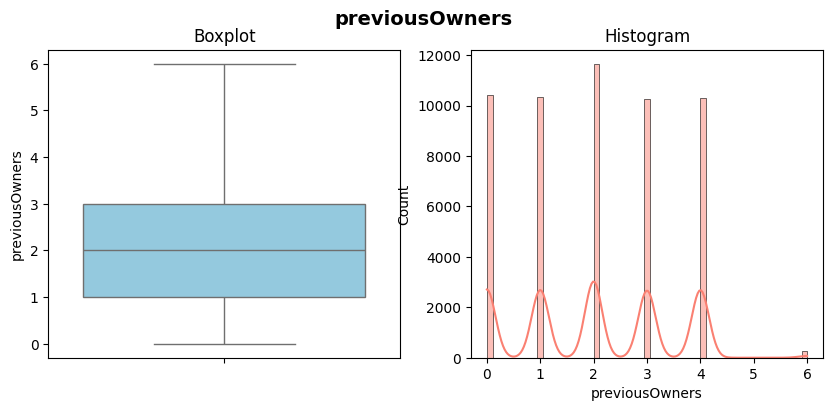

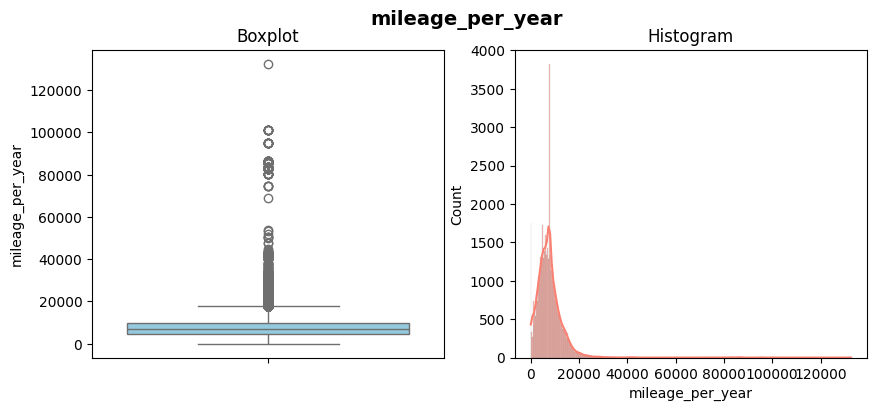

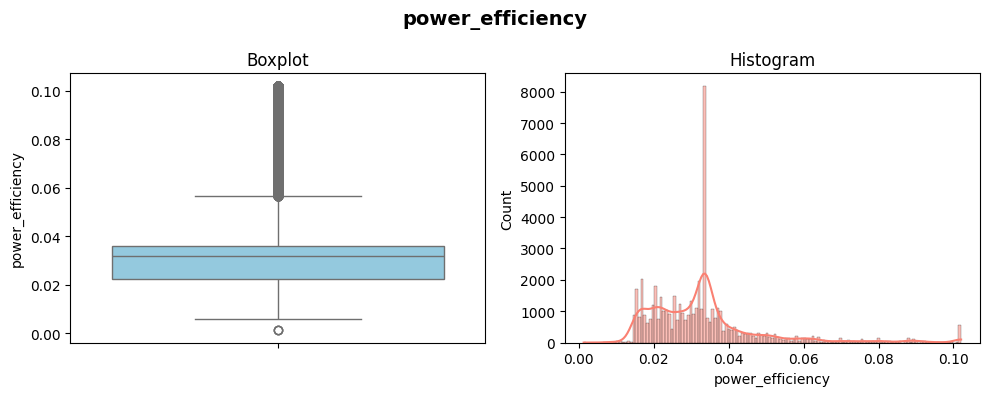

,Feature,Lower Outlier Count,Upper Outlier Count,Lower Outlier %,Upper Outlier %
0,year,0,1082,0.000000,2.034561
1,mileage,2299,2,4.322972,0.003761
2,tax,10941,2942,20.573137,5.532051
3,mpg,353,0,0.663771,0.000000
4,engineSize,0,0,0.000000,0.000000
5,previousOwners,0,0,0.000000,0.000000
6,mileage_per_year,0,1666,0.000000,3.132698
7,power_efficiency,3,3853,0.005641,7.245069


In [ ]:
plot_nums(X_train, num_cols)

Now most of our data is symetric , or only have a mild skew(-3,2).
The transformations that  used log , now have more outliers in the lower tail, which is to be expected, but in the other hand upper outliers are almost gone in theese features.  
The other transformation are now less influenced by extreme entries , which is the entire goal.


In [ ]:
X_train_num = X_train[num_cols].copy()
X_train_cat = X_train[cat_cols].copy()

X_val_num = X_val[num_cols].copy()
X_val_cat = X_val[cat_cols].copy()

In [ ]:
scaler = MinMaxScaler()
scaler.fit(X_train_num)
X_train_num_scaled = scaler.transform(X_train_num)
X_train_num_scaled

array([[2.00000000e-02, 6.32047387e-01, 2.90240663e-01, ...,
        3.33333333e-01, 2.95147080e-02, 2.56687257e-01],
       [2.00000000e-02, 6.63174786e-01, 2.72275069e-01, ...,
        5.00000000e-01, 4.28737796e-02, 1.13852904e-01],
       [0.00000000e+00, 1.42153989e-01, 2.90240663e-01, ...,
        0.00000000e+00, 7.49930066e-05, 1.62997688e-01],
       ...,
       [1.00000000e-01, 8.41769991e-01, 4.88517820e-02, ...,
        1.66666667e-01, 7.30206509e-02, 1.45377247e-01],
       [6.00000000e-02, 8.19780550e-01, 2.54162820e-01, ...,
        6.66666667e-01, 9.34904880e-02, 2.57654637e-01],
       [1.00000000e-01, 8.33550553e-01, 2.54162820e-01, ...,
        0.00000000e+00, 6.61662107e-02, 3.34112766e-01]])

In [ ]:
X_train_num_scaled = pd.DataFrame(X_train_num_scaled, columns = X_train_num.columns).set_index(X_train.index)
X_train_num_scaled

,year,mileage,tax,mpg,engineSize,previousOwners,mileage_per_year,power_efficiency
carID,,,,,,,,
39423,0.02,0.632047,0.290241,0.604651,0.15,0.333333,0.029515,0.256687
9016,0.02,0.663175,0.272275,1.000000,0.50,0.500000,0.042874,0.113853
24121,0.00,0.142154,0.290241,0.715762,0.00,0.000000,0.000075,0.162998
57460,0.04,0.774445,0.290241,0.492248,0.20,0.000000,0.081421,0.341779
1936,0.00,0.609856,0.290241,0.361757,0.95,0.166667,0.022617,0.976337
...,...,...,...,...,...,...,...,...
33819,0.06,0.765346,0.247688,0.649871,0.20,0.666667,0.048669,0.257655
46982,0.02,0.327042,0.290241,0.538760,0.50,0.333333,0.000754,0.451088
71103,0.10,0.841770,0.048852,0.797158,0.00,0.166667,0.073021,0.145377


In [ ]:
X_val_num_scaled = scaler.transform(X_val_num)
X_val_num_scaled = pd.DataFrame(X_val_num_scaled, columns = X_val_num.columns).set_index(X_val.index)
X_val_num_scaled

,year,mileage,tax,mpg,engineSize,previousOwners,mileage_per_year,power_efficiency
carID,,,,,,,,
7082,0.02,0.657676,0.290241,0.453488,0.50,0.166667,0.040137,0.535637
40497,0.08,0.790559,0.247688,0.698726,0.55,0.500000,0.049389,0.322680
46065,0.10,0.830727,0.961498,0.357881,1.00,0.500000,0.063963,1.000000
17155,0.04,0.764732,0.290241,0.687339,0.00,0.666667,0.072468,0.170114
34462,0.04,0.809777,0.290241,0.472868,0.75,0.166667,0.124381,0.645439
...,...,...,...,...,...,...,...,...
50530,0.06,0.766156,0.290241,0.779070,0.00,0.333333,0.049144,0.148980
41012,0.02,0.601197,0.290241,0.698726,0.50,0.333333,0.020385,0.322680
68389,0.06,0.810461,0.048852,0.815245,0.00,0.333333,0.083604,0.141931


In [ ]:
X_train_num_scaled.var()

year                0.001818
mileage             0.016104
tax                 0.013184
mpg                 0.020445
engineSize          0.065608
previousOwners      0.056276
mileage_per_year    0.001894
power_efficiency    0.024134
dtype: float64

In [ ]:
X_train_num.var()

year                       4.545941
mileage                    2.315915
tax                        1.000019
mpg                      122.483658
engineSize                 0.262432
previousOwners             2.025928
mileage_per_year    33323813.264794
power_efficiency           0.000245
dtype: Float64

## Unilateral correlation tests

Pearson Correlation

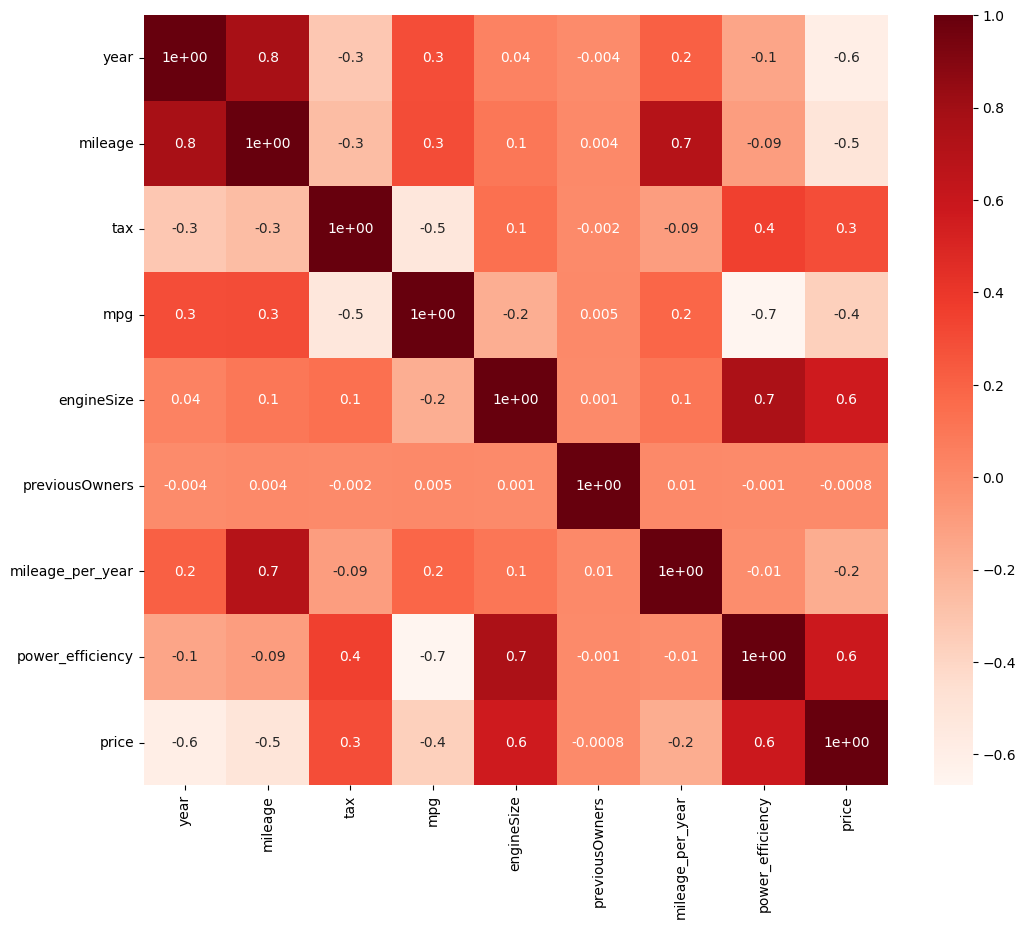

In [ ]:
corr = X_train_num_scaled.assign(price=y_train).corr(method="spearman")
def cor_heatmap(cor):
    plt.figure(figsize=(12,10))
    sns.heatmap(data = cor, annot = True, cmap = plt.cm.Reds, fmt='.1')
    plt.show()
cor_heatmap(corr)

In [ ]:
def spearman_decision(X_train_num_scaled,y_train,threshold=0.3):
    corr = X_train_num_scaled.assign(price=y_train).corr(method="spearman")["price"]
    corr = corr.drop("price")
    return pd.DataFrame({
        "value": corr,
        "decision": corr.abs() >= threshold
    })

In [ ]:
spearman = spearman_decision(X_train_num_scaled, y_train)
print(spearman)

                     value  decision
year             -0.590325      True
mileage          -0.508111      True
tax               0.292912     False
mpg              -0.366067      True
engineSize        0.567372      True
previousOwners   -0.000763     False
mileage_per_year -0.176538     False
power_efficiency  0.579713      True


All features have a high degree of correlation with price exept previous owners.

Mi scores

In [ ]:
def mi_scores_decision(X_train_num_scaled,y_train,threshold=0.01):
#How much knowing feature X reduces uncertainty about y
    mi_scores = mutual_info_regression(X_train_num_scaled.values.reshape(-1, 1), y_train, random_state=0)[0]
    return {
        "value": mi_scores,
        "decision": mi_scores >= threshold
    }


In [ ]:
res={}
for col in X_train_num.columns:
    res[col]=mi_scores_decision(X_train_num_scaled[col],y_train)
mi=pd.DataFrame(res).T
print(mi)

                     value decision
year              0.324695     True
mileage           0.304389     True
tax               0.190109     True
mpg                0.36219     True
engineSize        0.376479     True
previousOwners           0    False
mileage_per_year  0.154074     True
power_efficiency  0.665846     True


Mi scores assigns high correlation(in relationship to the target) , to all features exept tax,milleages_per_year and previousOwners.
It's worth noting that mi scores assigns an higher correlation to power_efficiency than to engineSize and year which is departure from the spearman method.  
Power efficiency is the main driver of mi scores, by a large distance.

Cramer's correlation

In [ ]:
def cramers_v_with_decision(x, y,threshold=0.3):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    result =  np.sqrt(chi2 / (n * (min(k - 1, r - 1))))
    return {
        "value": result,
        "decision": result >= threshold
    }

In [ ]:
res={}
for col in X_train_cat.columns:
    res[col]=cramers_v_with_decision(X_train_cat[col],y_train)
crammer=pd.DataFrame(res).T
print(crammer)

                 value decision
Brand         0.499467     True
model         0.480397     True
transmission  0.483131     True
fuelType      0.402262     True


ANOVA correlation

In [ ]:
def anova_eta_squared_decide(X, y,threshold=0.05):
    df = pd.DataFrame({"X": X, "y": y}).dropna()
    groups = [df[df["X"] == level]["y"] for level in df["X"].unique()]

    f_stat, _ = f_oneway(*groups)

    k = len(groups)
    n = len(df)
    value=(f_stat * (k - 1)) / (f_stat * (k - 1) + (n - k))
    return {
        "value": value,
        "decision": value >= threshold
    }

In [ ]:
res={}
for col in X_train_cat.columns:
    res[col]=anova_eta_squared_decide(X_train_cat[col],y_train)
anova=pd.DataFrame(res).T
print(anova)

                 value decision
Brand         0.287023     True
model           0.5721     True
transmission  0.299793     True
fuelType      0.046355    False


Strongest correlation is Model,followed by brand and transmission , while fuelType fails anova(at a 5% level).

RFE

We first have to find the optimal number of features to select , in our case it was 7.

In [ ]:
nof_list = np.arange(1, len(X_train_num_scaled.columns) + 1)
best_score = np.inf
best_n = 0

train_score_list = []
val_score_list = []

for n in nof_list:
    model = LinearRegression()
    rfe = RFE(estimator=model, n_features_to_select=n)

    # Fit RFE on training data
    X_train_rfe = rfe.fit_transform(X_train_num_scaled, y_train)
    X_val_rfe = rfe.transform(X_val_num_scaled)

    # Fit model
    model.fit(X_train_rfe, y_train)

    # Predict
    y_train_pred = model.predict(X_train_rfe)
    y_val_pred = model.predict(X_val_rfe)

    # Compute RMSE manually
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))

    # Store negated RMSE (so higher = better for plotting)
    train_score_list.append(-train_rmse)
    val_score_list.append(-val_rmse)

    # Track best score (lowest RMSE)
    if val_rmse < best_score:
        best_score = val_rmse
        best_n = n

print(f"Optimum number of features: {best_n}")
print(f"Lowest validation RMSE ({best_n} features): {best_score:.4f}")

Optimum number of features: 7
Lowest validation RMSE (7 features): 5233.6839


In [ ]:
def rfe_decision(X_train_num_scaled,y_train,n_features=best_n):
    rfe = RFE(estimator = LinearRegression(), n_features_to_select = best_n)
    rfe.fit(X = X_train_num_scaled, y = y_train)
    selected_feature= pd.Series(rfe.support_, index = X_train_num_scaled.columns,name="rfe")
    return selected_feature


In [ ]:
rfe = rfe_decision(
    X_train_num_scaled,
    y_train,
    n_features=best_n
)
print(rfe)

year                 True
mileage              True
tax                  True
mpg                  True
engineSize           True
previousOwners      False
mileage_per_year     True
power_efficiency     True
Name: rfe, dtype: bool


We used an RFE fitted with a simple linear regressior to rank importance.  
RFE ranks previousOwners has not significant

LASSO

In [ ]:
def lasso_decision(X_train_num_scaled,y_train):
    reg = LassoCV(cv=5, random_state=RANDOM_SEED)
    reg.fit(X_train_num_scaled, y_train)
    coef = pd.Series(reg.coef_, index = X_train_num_scaled.columns)

    return (coef.abs() > 1e-6)

In [ ]:
lasso_keep = lasso_decision(X_train_num_scaled, y_train)
print(lasso_keep)

year                 True
mileage              True
tax                  True
mpg                 False
engineSize           True
previousOwners       True
mileage_per_year     True
power_efficiency     True
dtype: bool


Lasso sets mpg as irrelevant

## Voting Table

In our voting table we will use spearman, mi and rfe has the 3 major deciders and Lasso will be the the final decider(has lasso can handly multicollinearity and pick the "strongest one")
Here's our decision criteria for numerical features :  
If a feature doesn't have a single passing test , then we will treat this feature has pure noise by not include the feature in any of our model(NOISE)  
If a feature passes all 3 major deciders we will assume it's major driver of price prediction(MAJOR)
If a features passes 2 out of three major decider we will let Lasso decide if we keep a lesser signal(KEEP) or we let feature be tossed(TOSS) , this features might be included in tree models due to the fact that tree dynamicaly weight features and they might be  relevant if they have some predictive power  even if some noise is present.   
If a feature only passes 1 test out of three we will confidently toss(HARD TOSS).

For categorical features , we will treat cramer's V and Anova has the 2 major deciders,has such the criteria will be :   
If Anova and Cramer are passed the we keep.(MAJOR)  
If 1 of the decidir is missing we tie break with Chi(Try)  
If both fail we fail(HARD FAIL)    

In [ ]:
def decide_numerical(
    spearman_decision: bool,
    mi_decision: bool,
    rfe_decision: bool,
    lasso_decision: bool
):
    votes = sum([spearman_decision, mi_decision, rfe_decision])

    if votes == 0:
        return "NOISE"

    if votes == 3:
        return "MAJOR"

    if votes == 2:
        return "KEEP" if lasso_decision else "TOSS"

    return "HARD TOSS"


In [ ]:
numerical_decisions = {}

for col in X_train_num_scaled.columns:
    numerical_decisions[col] = {
        "decision": decide_numerical(
            spearman_decision=spearman.loc[col, "decision"],
            mi_decision=mi.loc[col, "decision"],
            rfe_decision=rfe[col],
            lasso_decision=lasso_keep[col]
        )
    }

numerical_results = pd.DataFrame(numerical_decisions).T
print(numerical_results)

                 decision
year                MAJOR
mileage             MAJOR
tax                  KEEP
mpg                 MAJOR
engineSize          MAJOR
previousOwners      NOISE
mileage_per_year     KEEP
power_efficiency    MAJOR


In [ ]:
def decide_categorical(
    cramers_pass: bool,
    anova_pass: bool
):
    if cramers_pass and anova_pass:
        return "MAJOR"

    if cramers_pass or anova_pass:
        return "TRY"

    return "HARD FAIL"

In [ ]:
categorical_decisions = {}
for col in X_train_cat.columns:
    cv = cramers_v_with_decision(X_train_cat[col], y_train)
    av = anova_eta_squared_decide(X_train_cat[col], y_train)

    categorical_decisions[col] = {
        "cramers": cv["value"],
        "anova": av["value"],
        "decision": decide_categorical(
            cramers_pass=cv["decision"],
            anova_pass=av["decision"]
        )
    }

categorical_results = pd.DataFrame(categorical_decisions).T
print(categorical_results)

               cramers     anova decision
Brand         0.499467  0.287023    MAJOR
model         0.480397    0.5721    MAJOR
transmission  0.483131  0.299793    MAJOR
fuelType      0.402262  0.046355      TRY
